# Question 1 — descriptive analysis, contextual associations and borough clustering

This notebook describes the nine prepared panels, quantifies uncertainty, separates spatial and
temporal associations, and tests whether boroughs form a stable, interpretable grouping. The
contextual regressions are exploratory and non-causal; forecasting remains in Notebook 03. All
rates use the survey weights prepared and validated in Notebook 01.

> **Primary limitation.** A borough-month has a small effective sample in many periods, so monthly
> borough estimates are exploratory. Approximate confidence intervals use Kish effective sample
> size and are diagnostics rather than full complex-survey design intervals.


In [1]:
from pathlib import Path
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import probplot
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor


os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'data'
RESULTS_DIR = OUTPUT_ROOT / 'results'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'london_annual': DATA_DIR / 'q1_london_annual.csv',
    'area_annual': DATA_DIR / 'q1_inner_outer_annual.csv',
    'borough_annual': DATA_DIR / 'q1_borough_annual.csv',
    'london_monthly': DATA_DIR / 'q1_london_monthly.csv',
    'area_monthly': DATA_DIR / 'q1_inner_outer_monthly.csv',
    'borough_monthly': DATA_DIR / 'q1_borough_monthly.csv',
    'london_quarterly': DATA_DIR / 'q1_london_quarterly.csv',
    'area_quarterly': DATA_DIR / 'q1_inner_outer_quarterly.csv',
    'borough_quarterly': DATA_DIR / 'q1_borough_quarterly.csv',
}
RESULTS_PATH = RESULTS_DIR / 'q1_descriptive_and_clustering.xlsx'
AUDIT_PATH = DATA_DIR / 'q1_preparation_audit.xlsx'
BOUNDARY_PATH = DATA_DIR / 'london_borough_boundaries.geojson'
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
RANDOM_STATE = 2026


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return path


## 1. Load and validate the nine prepared panels

Notebook 01 performs respondent-level and panel-level validation. This section repeats the
analysis-facing contract: dimensions, unique keys, time coverage, rate bounds, compositional
coherence, missing outcomes and positive effective sample sizes. The one known missing
borough-month is reported rather than silently discarded.


In [2]:
panels = {name: pd.read_csv(path) for name, path in PATHS.items()}
for name in ['london_monthly', 'area_monthly', 'borough_monthly']:
    panels[name]['period_start'] = pd.to_datetime(panels[name]['period_start'])
for name in ['london_quarterly', 'area_quarterly', 'borough_quarterly']:
    panels[name]['quarter_start'] = pd.to_datetime(panels[name]['quarter_start'])
    panels[name]['quarter_end'] = pd.to_datetime(panels[name]['quarter_end'])
globals().update(panels)

age_london_annual = pd.read_excel(AUDIT_PATH, sheet_name='age_london_annual')
age_area_annual = pd.read_excel(AUDIT_PATH, sheet_name='age_inner_outer_annual')
age_borough_annual = pd.read_excel(AUDIT_PATH, sheet_name='age_borough_annual')
preparation_panel_summary = pd.read_excel(AUDIT_PATH, sheet_name='panel_summary')
external_sources = pd.read_excel(AUDIT_PATH, sheet_name='external_sources')
external_quality = pd.read_excel(AUDIT_PATH, sheet_name='external_quality')

EXPECTED = {
    'london_annual': (['year'], 8, 1, 0),
    'area_annual': (['year', 'geography_code'], 16, 2, 0),
    'borough_annual': (['year', 'geography_code'], 256, 32, 0),
    'london_quarterly': (['quarter_index'], 32, 1, 0),
    'area_quarterly': (['quarter_index', 'geography_code'], 64, 2, 0),
    'borough_quarterly': (['quarter_index', 'geography_code'], 1024, 32, 0),
    'london_monthly': (['month_index'], 96, 1, 0),
    'area_monthly': (['month_index', 'geography_code'], 192, 2, 0),
    'borough_monthly': (['month_index', 'geography_code'], 3072, 32, 1),
}

validation_rows = []
for name, frame in panels.items():
    keys, expected_rows, expected_geographies, expected_missing_rows = EXPECTED[name]
    complete = frame[TARGETS].notna().all(axis=1)
    observed = frame.loc[complete]
    composition_error = observed[TARGETS].sum(axis=1).sub(1).abs().max()
    row = {
        'panel': name,
        'rows': len(frame),
        'expected_rows': expected_rows,
        'geographies': frame['geography_code'].nunique(),
        'duplicate_keys': int(frame.duplicated(keys).sum()),
        'missing_target_rows': int((~complete).sum()),
        'missing_target_cells': int(frame[TARGETS].isna().sum().sum()),
        'out_of_range_target_cells': int((~observed[TARGETS].apply(lambda x: x.between(0, 1))).sum().sum()),
        'max_composition_error': composition_error,
        'nonpositive_effective_n': int(frame['effective_n'].le(0).sum()),
    }
    validation_rows.append(row)
    assert len(frame) == expected_rows
    assert frame['geography_code'].nunique() == expected_geographies
    assert not frame.duplicated(keys).any()
    assert int((~complete).sum()) == expected_missing_rows
    assert row['out_of_range_target_cells'] == 0
    assert composition_error < 1e-10
    assert row['nonpositive_effective_n'] == 0

panel_validation = pd.DataFrame(validation_rows)
missing_outcome_rows = borough_monthly.loc[
    borough_monthly[TARGETS].isna().any(axis=1),
    ['month_index', 'period_start', 'geography_code', 'geography_name', *TARGETS, 'effective_n'],
]
display(panel_validation)
display(missing_outcome_rows)


,panel,rows,expected_rows,geographies,duplicate_keys,missing_target_rows,missing_target_cells,out_of_range_target_cells,max_composition_error,nonpositive_effective_n
0,london_annual,8,8,1,0,0,0,0,2.220446e-16,0
1,area_annual,16,16,2,0,0,0,0,2.220446e-16,0
2,borough_annual,256,256,32,0,0,0,0,4.440892e-16,0
3,london_monthly,96,96,1,0,0,0,0,2.220446e-16,0
4,area_monthly,192,192,2,0,0,0,0,4.440892e-16,0
5,borough_monthly,3072,3072,32,0,1,3,0,5.551115e-16,0
6,london_quarterly,32,32,1,0,0,0,0,3.330669e-16,0
7,area_quarterly,64,64,2,0,0,0,0,3.330669e-16,0
8,borough_quarterly,1024,1024,32,0,0,0,0,4.440892e-16,0


,month_index,period_start,geography_code,geography_name,inactive_rate,fairly_active_rate,active_rate,effective_n
1888,60,2020-10-01,E09000002,Barking and Dagenham,NaN,NaN,NaN,NaN


### Coverage against the intended framework

Population/migration, residence-based earnings and recorded crime are present in all shared
panels. Economic inactivity and weather are not available in Notebook 01 or the project data
directory. They are recorded as upstream extensions rather than joined only here, which preserves
the common data contract used by Notebook 03. Relative-to-London earnings are used for borough
comparison and modelling; nominal earnings remain available only for descriptive levels.


In [3]:
analysis_coverage_register = pd.DataFrame([
    {'domain': 'Physical activity', 'status': 'Retained',
     'implementation': 'Weighted activity composition at three frequencies and geographic levels'},
    {'domain': 'Population and migration', 'status': 'Retained',
     'implementation': 'ONS adult composition and net migration'},
    {'domain': 'Income', 'status': 'Retained and revised',
     'implementation': 'Relative-to-London residence-based earnings for comparison and modelling'},
    {'domain': 'Recorded crime', 'status': 'Retained',
     'implementation': 'One non-duplicated selected-crime total in multivariate analysis'},
    {'domain': 'Economic inactivity', 'status': 'Upstream data gap',
     'implementation': 'Not present in Notebook 01 panels; no proxy or one-off join is fabricated'},
    {'domain': 'Weather', 'status': 'Upstream data gap',
     'implementation': 'Not present in Notebook 01 panels; requires a defined spatial-temporal source'},
    {'domain': 'Spatial boundaries', 'status': 'Added for description',
     'implementation': 'GLA borough polygons; City of London excluded to match the 32-borough study'},
])
display(analysis_coverage_register)


,domain,status,implementation
0,Physical activity,Retained,Weighted activity composition at three frequen...
1,Population and migration,Retained,ONS adult composition and net migration
2,Income,Retained and revised,Relative-to-London residence-based earnings fo...
3,Recorded crime,Retained,One non-duplicated selected-crime total in mul...
4,Economic inactivity,Upstream data gap,Not present in Notebook 01 panels; no proxy or...
5,Weather,Upstream data gap,Not present in Notebook 01 panels; requires a ...
6,Spatial boundaries,Added for description,GLA borough polygons; City of London excluded ...


## 2. Precision and approximate uncertainty

Kish effective sample size is a precision diagnostic, not a formal suppression threshold. Normal
approximation intervals below use `p(1-p)/effective_n`; they make uncertainty visible but do not
replace replicate-weight or full complex-survey intervals.


,geographic_level,frequency,observations,median_effective_n,p25_effective_n,share_below_20,share_below_30
0,London,Monthly,96,746.4,661.6,0.0%,0.0%
1,London,Quarterly,32,2133.7,2025.6,0.0%,0.0%
2,London,Annual,8,9163.0,8747.6,0.0%,0.0%
3,Inner/Outer,Monthly,192,366.0,290.8,0.0%,0.0%
4,Inner/Outer,Quarterly,64,1070.8,845.8,0.0%,0.0%
5,Inner/Outer,Annual,16,4569.6,3770.3,0.0%,0.0%
6,Borough,Monthly,3072,25.2,19.8,25.8%,69.3%
7,Borough,Quarterly,1024,71.5,61.9,0.2%,1.0%
8,Borough,Annual,256,294.7,280.8,0.0%,0.0%


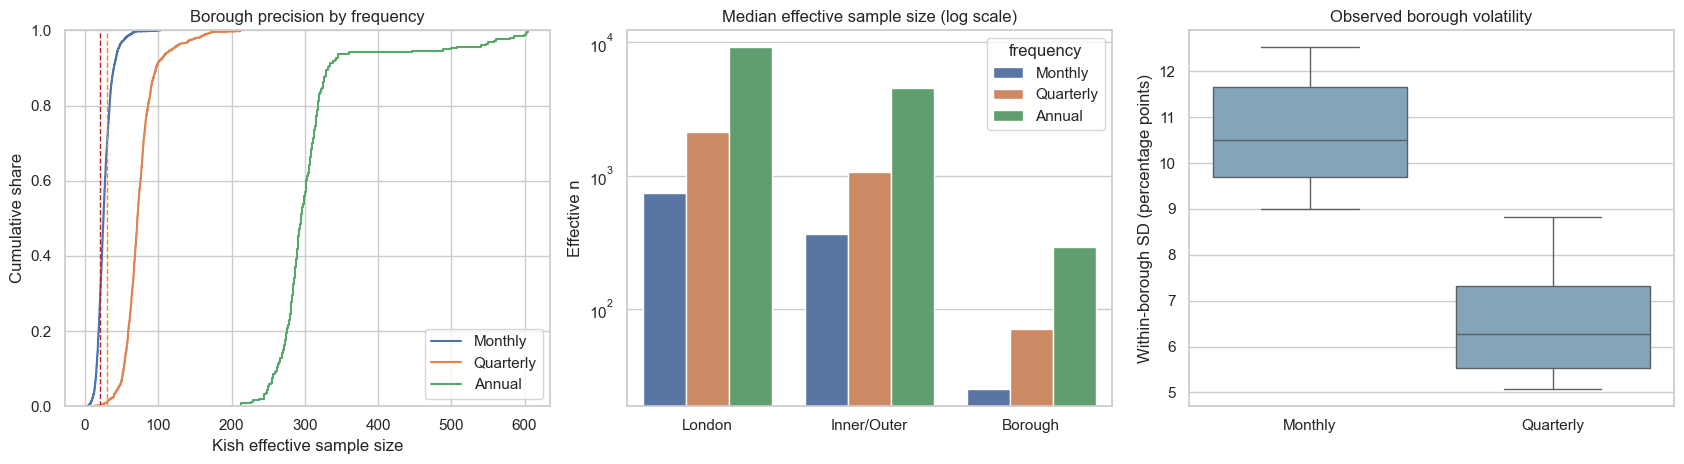

In [4]:
def precision_summary(frame, level, frequency):
    effective_n = frame['effective_n']
    return {
        'geographic_level': level, 'frequency': frequency, 'observations': len(frame),
        'median_effective_n': effective_n.median(),
        'p25_effective_n': effective_n.quantile(.25),
        'share_below_20': effective_n.lt(20).mean(),
        'share_below_30': effective_n.lt(30).mean(),
    }


def add_rate_uncertainty(frame, targets=TARGETS):
    result = frame.copy()
    for target in targets:
        standard_error = np.sqrt(result[target] * (1 - result[target]) / result['effective_n'])
        result[f'{target}_se'] = standard_error
        result[f'{target}_low'] = (result[target] - 1.96 * standard_error).clip(0, 1)
        result[f'{target}_high'] = (result[target] + 1.96 * standard_error).clip(0, 1)
    return result


precision_table = pd.DataFrame([
    precision_summary(panels[f'{prefix}_{frequency}'], level, frequency.title())
    for prefix, level in [('london', 'London'), ('area', 'Inner/Outer'), ('borough', 'Borough')]
    for frequency in ['monthly', 'quarterly', 'annual']
])
display(precision_table.style.format({
    'median_effective_n': '{:.1f}', 'p25_effective_n': '{:.1f}',
    'share_below_20': '{:.1%}', 'share_below_30': '{:.1%}',
}))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for frequency, frame in [('Monthly', borough_monthly), ('Quarterly', borough_quarterly),
                         ('Annual', borough_annual)]:
    sns.ecdfplot(frame['effective_n'], label=frequency, ax=axes[0])
axes[0].axvline(20, color='firebrick', linestyle='--', linewidth=1)
axes[0].axvline(30, color='darkorange', linestyle='--', linewidth=1)
axes[0].set(title='Borough precision by frequency', xlabel='Kish effective sample size',
            ylabel='Cumulative share')
axes[0].legend()

sns.barplot(data=precision_table, x='geographic_level', y='median_effective_n',
            hue='frequency', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set(title='Median effective sample size (log scale)', xlabel='', ylabel='Effective n')

monthly_sd = borough_monthly.groupby('geography_name')['active_rate'].std().rename('Monthly')
quarterly_sd = borough_quarterly.groupby('geography_name')['active_rate'].std().rename('Quarterly')
variability = pd.concat([monthly_sd, quarterly_sd], axis=1).mul(100).reset_index()
variability_long = variability.melt('geography_name', var_name='Frequency', value_name='SD')
sns.boxplot(data=variability_long, x='Frequency', y='SD', ax=axes[2], color='#7aa6c2')
axes[2].set(title='Observed borough volatility', xlabel='',
            ylabel='Within-borough SD (percentage points)')
fig.tight_layout()
save_figure(fig, 'sample_precision_across_geographic_levels.png')
plt.show()


### Findings

- London and Inner/Outer estimates are well supported at every frequency.
- The borough-month median effective sample is about **25**, and roughly **69%** of cells are below
  30; monthly borough results therefore remain exploratory.
- Direct quarterly pooling raises the borough median effective sample to about **71**, making
  quarterly estimates materially less noisy while retaining within-year information.


## 3. Annual and monthly activity patterns with uncertainty

Annual estimates carry the main descriptive message. Approximate intervals are shown for annual
London and Year 8 borough values. The centred three-month rolling mean is used only for visualisation;
the shaded region marks disruption rather than a policy effect.


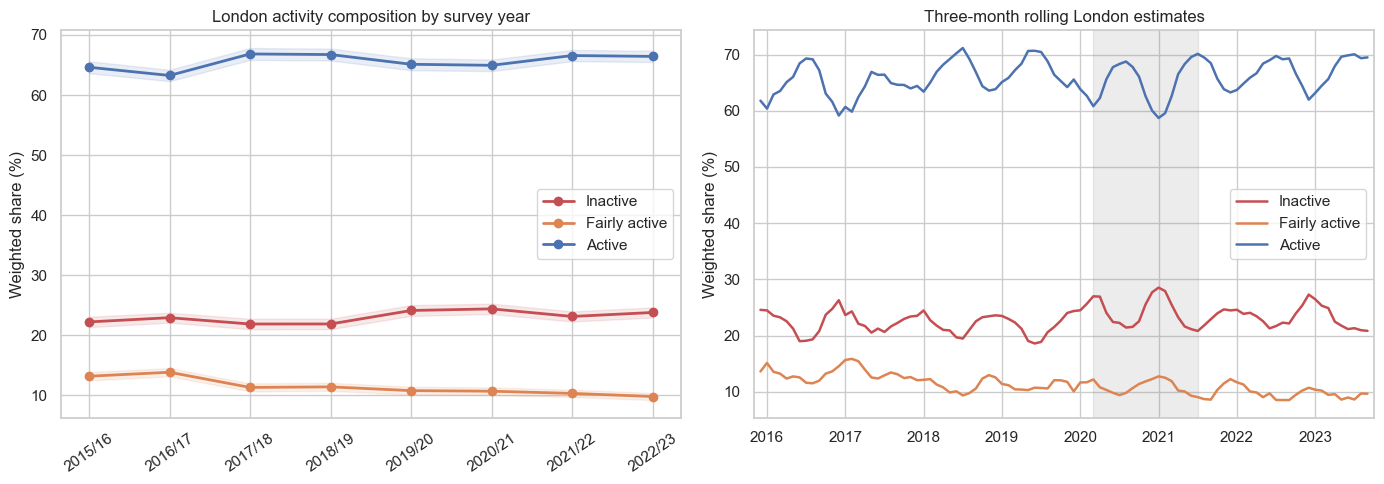

In [5]:
london_annual_ci = add_rate_uncertainty(london_annual)
annual_plot = london_annual_ci.set_index('survey_wave')[TARGETS].mul(100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'inactive_rate': '#c44e52', 'fairly_active_rate': '#dd8452', 'active_rate': '#4c72b0'}
for target in TARGETS:
    x = np.arange(len(london_annual_ci))
    axes[0].plot(x, london_annual_ci[target] * 100, marker='o', linewidth=2,
                 color=colors[target], label=TARGET_LABELS[target])
    axes[0].fill_between(x, london_annual_ci[f'{target}_low'] * 100,
                         london_annual_ci[f'{target}_high'] * 100,
                         color=colors[target], alpha=.12)
axes[0].set_xticks(x, london_annual_ci['survey_wave'], rotation=35)
axes[0].set(title='London activity composition by survey year', xlabel='', ylabel='Weighted share (%)')
axes[0].legend()

monthly_london = london_monthly.set_index('period_start')[TARGETS].rolling(3, center=True).mean().mul(100)
monthly_london.plot(ax=axes[1], linewidth=1.8, color=[colors[x] for x in TARGETS])
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.15)
axes[1].set(title='Three-month rolling London estimates', xlabel='', ylabel='Weighted share (%)')
axes[1].legend([TARGET_LABELS[column] for column in TARGETS])
fig.tight_layout()
save_figure(fig, 'activity_trends_annual_and_monthly.png')
plt.show()


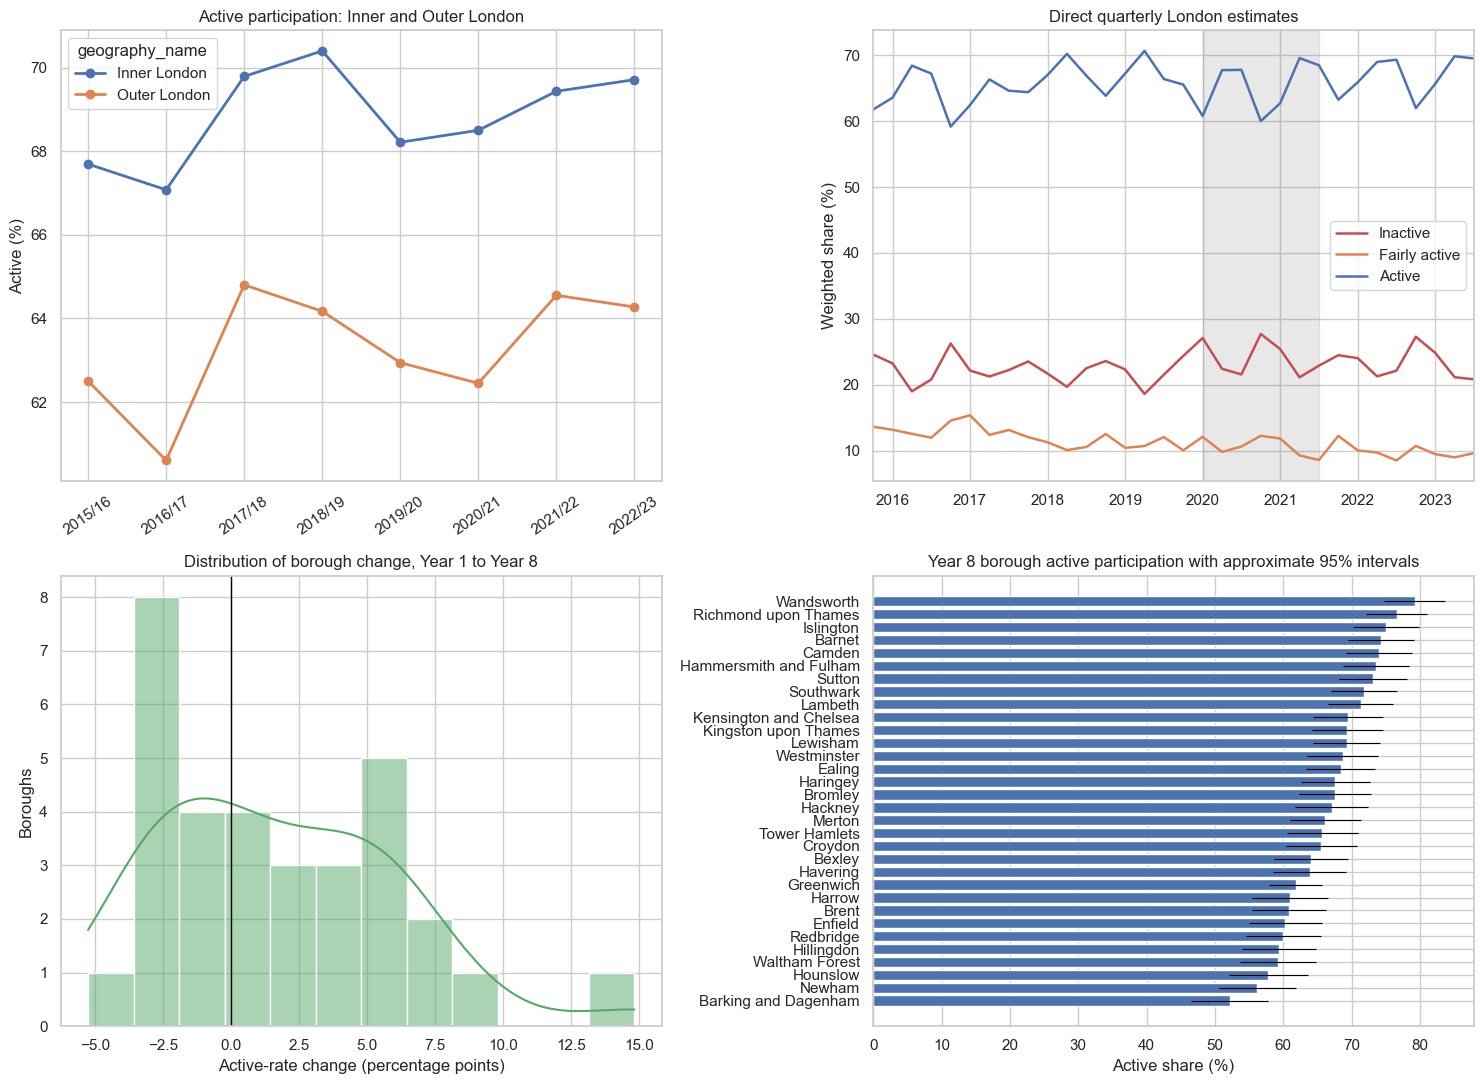

In [6]:
borough_annual_ci = add_rate_uncertainty(borough_annual)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
area_plot = area_annual.pivot(index='survey_wave', columns='geography_name', values='active_rate').mul(100)
area_plot.plot(marker='o', linewidth=2, ax=axes[0, 0])
axes[0, 0].set(title='Active participation: Inner and Outer London', xlabel='', ylabel='Active (%)')
axes[0, 0].tick_params(axis='x', rotation=35)

quarter_plot = london_quarterly.set_index('quarter_start')[TARGETS].mul(100)
quarter_plot.plot(linewidth=1.8, ax=axes[0, 1], color=[colors[x] for x in TARGETS])
axes[0, 1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.18)
axes[0, 1].set(title='Direct quarterly London estimates', xlabel='', ylabel='Weighted share (%)')
axes[0, 1].legend([TARGET_LABELS[column] for column in TARGETS])

start = borough_annual_ci.loc[borough_annual_ci['year'].eq(1)].set_index('geography_code')
end = borough_annual_ci.loc[borough_annual_ci['year'].eq(8)].set_index('geography_code')
borough_change = pd.DataFrame({
    'geography_name': end['geography_name'],
    'change_pp': (end['active_rate'] - start['active_rate']) * 100,
    'change_se_pp': np.sqrt(end['active_rate_se'] ** 2 + start['active_rate_se'] ** 2) * 100,
}).reset_index()
sns.histplot(borough_change['change_pp'], bins=12, kde=True, ax=axes[1, 0], color='#55a868')
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set(title='Distribution of borough change, Year 1 to Year 8',
               xlabel='Active-rate change (percentage points)', ylabel='Boroughs')

latest = borough_annual_ci.loc[borough_annual_ci['year'].eq(8)].sort_values('active_rate')
axes[1, 1].barh(latest['geography_name'], latest['active_rate'] * 100, color='#4c72b0')
axes[1, 1].errorbar(
    latest['active_rate'] * 100, latest['geography_name'],
    xerr=1.96 * latest['active_rate_se'] * 100, fmt='none', color='black', linewidth=.8,
)
axes[1, 1].set(title='Year 8 borough active participation with approximate 95% intervals',
               xlabel='Active share (%)', ylabel='')
fig.tight_layout()
save_figure(fig, 'geographic_activity_patterns.png')
plt.show()


### Findings

London-wide change is modest relative to the cross-borough spread. Approximate intervals show that
many adjacent positions in the Year 8 ranking are not meaningfully distinguishable. Borough change
is heterogeneous, so neither the London mean nor a precise league table should stand in for local
trajectories. London active participation rises by about **1.8 percentage points** from Year 1 to
Year 8, much less than the full borough change range.


### COVID-period activity-level magnitude

This section asks whether the pandemic period coincided with a small or material change in Active
participation. It does **not** claim a causal treatment effect: London has no untreated contemporaneous
control and the Oxford policy series is common to all boroughs. Instead it triangulates three auditable
quantities: the deviation from a pre-COVID seasonal trend, phase indicators with Newey-West uncertainty,
and a borough fixed-effects model with standard errors clustered by month.

The external signal is the final Oxford COVID-19 Government Response Tracker Stringency Index for
England (`GBR`, `UK_ENG`, `STATE_TOTAL`). It records policy strictness on a 0-100 scale, not compliance,
implementation quality or the appropriateness of the response. Source: [Oxford tracker](https://www.bsg.ox.ac.uk/research/covid-19-government-response-tracker)
and [final data repository](https://github.com/OxCGRT/covid-policy-dataset).


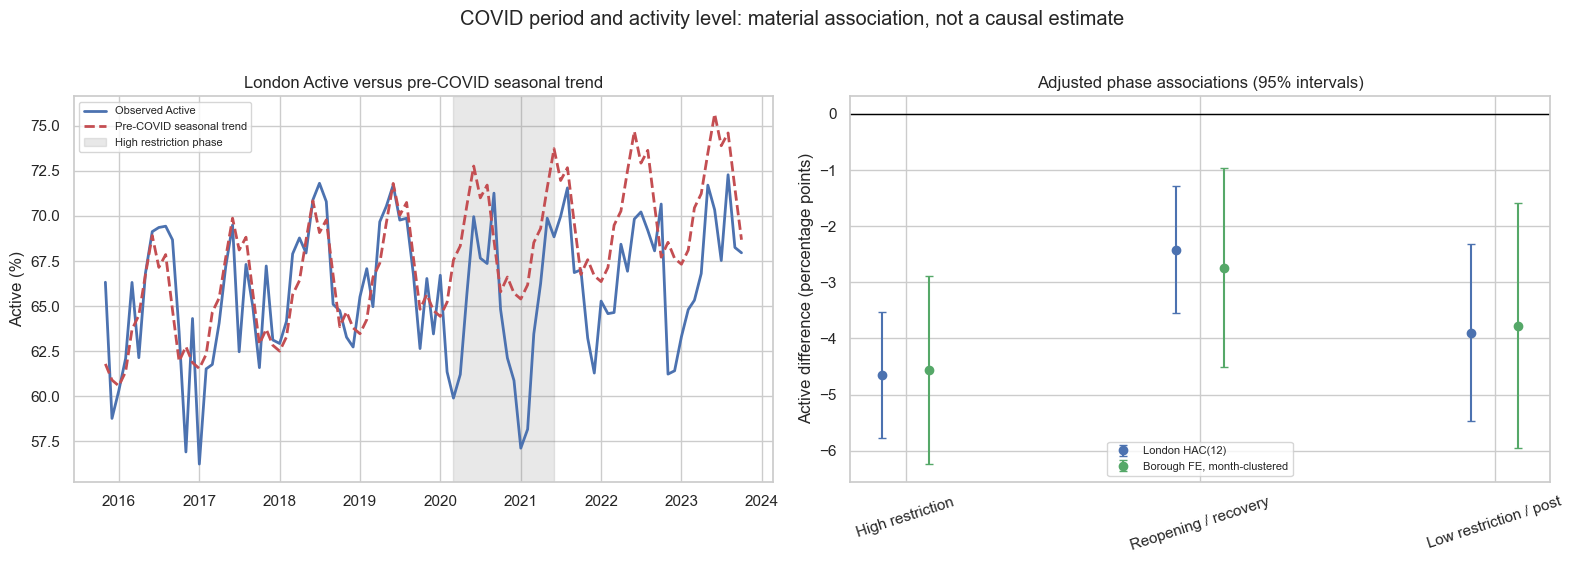

,covid_phase,months,mean_stringency_0_100,mean_inactive_rate_pct,mean_fairly_active_rate_pct,mean_active_rate_pct,pre_covid_seasonal_counterfactual_active_pct,active_counterfactual_gap_pp
0,Pre-COVID,52,0.228,22.102,12.223,65.675,65.675,0.000
1,High restriction,16,69.309,24.830,10.890,64.280,69.030,-4.750
2,Reopening/recovery,8,24.910,23.459,10.236,66.305,68.541,-2.236
3,Low restriction/post,20,7.206,22.982,9.553,67.465,71.208,-3.743


,specification,geographic_level,estimand,estimate_active_pp,standard_error,ci95_low,ci95_high,p_value,adjusts_online_response,observations,independent_months,covariance
0,London phase,London,High restriction versus Pre-COVID,-4.6602,0.5724,-5.7821,-3.5382,0.0000,False,96,96,HAC(12)
1,London phase,London,Reopening/recovery versus Pre-COVID,-2.4187,0.5760,-3.5476,-1.2898,0.0000,False,96,96,HAC(12)
2,London phase,London,Low restriction/post versus Pre-COVID,-3.9004,0.8053,-5.4787,-2.3221,0.0000,False,96,96,HAC(12)
3,London phase + online sensitivity,London,High restriction versus Pre-COVID,-4.5283,0.6243,-5.7520,-3.3046,0.0000,True,96,96,HAC(12)
4,London phase + online sensitivity,London,Reopening/recovery versus Pre-COVID,-2.6299,0.5604,-3.7283,-1.5315,0.0000,True,96,96,HAC(12)
5,London phase + online sensitivity,London,Low restriction/post versus Pre-COVID,-4.1921,0.7863,-5.7332,-2.6509,0.0000,True,96,96,HAC(12)
6,Borough FE phase,Borough,High restriction versus Pre-COVID,-4.5641,0.8544,-6.2388,-2.8895,0.0000,False,3071,96,Month-clustered
7,Borough FE phase,Borough,Reopening/recovery versus Pre-COVID,-2.7365,0.9079,-4.5160,-0.9571,0.0026,False,3071,96,Month-clustered
8,Borough FE phase,Borough,Low restriction/post versus Pre-COVID,-3.7768,1.1145,-5.9613,-1.5924,0.0007,False,3071,96,Month-clustered
9,Borough FE phase + online sensitivity,Borough,High restriction versus Pre-COVID,-4.6204,0.8629,-6.3117,-2.9291,0.0000,True,3071,96,Month-clustered


In [7]:
COVID_SOURCE_PATH = PROJECT_ROOT / 'data_integration' / 'external' / 'OxCGRT_timeseries_StringencyIndex_v1.csv'
assert COVID_SOURCE_PATH.exists(), f'Missing required COVID source: {COVID_SOURCE_PATH}'

oxford_covid = pd.read_csv(COVID_SOURCE_PATH)
england_covid = oxford_covid.loc[
    oxford_covid['CountryCode'].eq('GBR')
    & oxford_covid['RegionCode'].eq('UK_ENG')
    & oxford_covid['Jurisdiction'].eq('STATE_TOTAL')
]
assert len(england_covid) == 1
covid_date_columns = list(oxford_covid.columns[7:])
covid_daily = pd.DataFrame({
    'date': pd.to_datetime(covid_date_columns, format='%d%b%Y'),
    'stringency_index': pd.to_numeric(
        england_covid.iloc[0][covid_date_columns].to_numpy(), errors='coerce'
    ),
}).sort_values('date')
covid_first_observed = covid_daily.loc[covid_daily['stringency_index'].notna(), 'date'].min()
covid_last_observed = covid_daily.loc[covid_daily['stringency_index'].notna(), 'date'].max()
covid_last_value = covid_daily.loc[
    covid_daily['date'].eq(covid_last_observed), 'stringency_index'
].iloc[0]
covid_monthly_source = covid_daily.set_index('date')['stringency_index'].resample('MS').mean()

covid_calendar = pd.DataFrame({'period_start': london_monthly['period_start'].sort_values().unique()})
covid_calendar['covid_stringency'] = covid_calendar['period_start'].map(covid_monthly_source)
covid_calendar.loc[covid_calendar['period_start'].lt(covid_first_observed), 'covid_stringency'] = 0.0
covid_calendar.loc[covid_calendar['period_start'].gt(covid_last_observed), 'covid_stringency'] = covid_last_value
assert covid_calendar['covid_stringency'].notna().all()

COVID_PHASES = ['Pre-COVID', 'High restriction', 'Reopening/recovery', 'Low restriction/post']


def attach_covid_period(frame):
    result = frame.merge(covid_calendar, on='period_start', how='left', validate='many_to_one')
    result['active_pct'] = result['active_rate'] * 100
    result['time_trend'] = result['month_index'] - 1
    result['covid_phase'] = np.select(
        [
            result['period_start'].le(pd.Timestamp('2020-02-01')),
            result['period_start'].le(pd.Timestamp('2021-06-01')),
            result['period_start'].le(pd.Timestamp('2022-02-01')),
        ],
        COVID_PHASES[:3], default=COVID_PHASES[3],
    )
    result['covid_phase'] = pd.Categorical(
        result['covid_phase'], categories=COVID_PHASES, ordered=True
    )
    return result


covid_london = attach_covid_period(london_monthly)
covid_borough = attach_covid_period(borough_monthly)
pre_covid_london = covid_london.loc[covid_london['covid_phase'].eq('Pre-COVID')].dropna(
    subset=['active_pct', 'effective_n', 'time_trend', 'month_of_wave']
)
pretrend_model = smf.wls(
    'active_pct ~ time_trend + C(month_of_wave)',
    pre_covid_london, weights=pre_covid_london['effective_n'],
).fit()
covid_london['pre_covid_seasonal_counterfactual_pct'] = pretrend_model.predict(covid_london)
covid_london['counterfactual_gap_pp'] = (
    covid_london['active_pct'] - covid_london['pre_covid_seasonal_counterfactual_pct']
)

covid_phase_rows = []
for phase, group in covid_london.groupby('covid_phase', observed=True):
    weights = group['effective_n']
    covid_phase_rows.append({
        'covid_phase': phase,
        'months': len(group),
        'mean_stringency_0_100': np.average(group['covid_stringency'], weights=weights),
        **{
            f'mean_{target}_pct': 100 * np.average(group[target], weights=weights)
            for target in TARGETS
        },
        'pre_covid_seasonal_counterfactual_active_pct': np.average(
            group['pre_covid_seasonal_counterfactual_pct'], weights=weights
        ),
        'active_counterfactual_gap_pp': np.average(group['counterfactual_gap_pp'], weights=weights),
    })
covid_phase_summary = pd.DataFrame(covid_phase_rows)

phase_term = 'C(covid_phase, Treatment(reference="Pre-COVID"))'
phase_formula = f'active_pct ~ time_trend + C(month_of_wave) + {phase_term}'
borough_phase_formula = f'active_pct ~ C(geography_code) + time_trend + C(month_of_wave) + {phase_term}'
covid_model_specs = [
    ('London phase', 'London', covid_london, phase_formula, 'HAC(12)', False),
    ('London phase + online sensitivity', 'London', covid_london,
     phase_formula + ' + online_response_rate', 'HAC(12)', True),
    ('Borough FE phase', 'Borough', covid_borough, borough_phase_formula,
     'Month-clustered', False),
    ('Borough FE phase + online sensitivity', 'Borough', covid_borough,
     borough_phase_formula + ' + online_response_rate', 'Month-clustered', True),
    ('London continuous stringency', 'London', covid_london,
     'active_pct ~ time_trend + C(month_of_wave) + I(covid_stringency / 10)',
     'HAC(12)', False),
    ('Borough FE continuous stringency', 'Borough', covid_borough,
     'active_pct ~ C(geography_code) + time_trend + C(month_of_wave) + I(covid_stringency / 10)',
     'Month-clustered', False),
]

covid_estimate_rows = []
for specification, level, frame, formula, covariance, adjusts_online in covid_model_specs:
    required = [
        'active_pct', 'effective_n', 'month_index', 'time_trend', 'month_of_wave',
        'covid_phase', 'covid_stringency', 'geography_code',
    ] + (['online_response_rate'] if adjusts_online else [])
    fit_frame = frame[required].dropna().copy()
    fitted = smf.wls(formula, fit_frame, weights=fit_frame['effective_n']).fit(
        cov_type='cluster',
        cov_kwds={'groups': fit_frame['month_index'], 'use_correction': True},
    ) if level == 'Borough' else smf.wls(
        formula, fit_frame, weights=fit_frame['effective_n']
    ).fit(cov_type='HAC', cov_kwds={'maxlags': 12})

    requested_terms = (
        [(f'{phase_term}[T.{phase}]', f'{phase} versus Pre-COVID') for phase in COVID_PHASES[1:]]
        if 'phase' in specification else
        [('I(covid_stringency / 10)', 'Per 10-point higher Stringency Index')]
    )
    intervals = fitted.conf_int()
    for term, estimand in requested_terms:
        covid_estimate_rows.append({
            'specification': specification,
            'geographic_level': level,
            'estimand': estimand,
            'estimate_active_pp': fitted.params[term],
            'standard_error': fitted.bse[term],
            'ci95_low': intervals.loc[term, 0],
            'ci95_high': intervals.loc[term, 1],
            'p_value': fitted.pvalues[term],
            'adjusts_online_response': adjusts_online,
            'observations': len(fit_frame),
            'independent_months': fit_frame['month_index'].nunique(),
            'covariance': covariance,
        })
covid_model_estimates = pd.DataFrame(covid_estimate_rows)

covid_source_register = pd.DataFrame([{
    'source': 'Oxford COVID-19 Government Response Tracker final Stringency Index',
    'jurisdiction': 'England STATE_TOTAL (GBR / UK_ENG)',
    'first_observed_date': covid_first_observed,
    'last_observed_date': covid_last_observed,
    'last_observed_value_0_100': covid_last_value,
    'licence': 'CC BY 4.0',
    'interpretation': 'Recorded policy strictness; not implementation, compliance or causal exposure',
}])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].plot(covid_london['period_start'], covid_london['active_pct'],
             color='#4c72b0', linewidth=2, label='Observed Active')
axes[0].plot(covid_london['period_start'], covid_london['pre_covid_seasonal_counterfactual_pct'],
             color='#c44e52', linestyle='--', linewidth=2, label='Pre-COVID seasonal trend')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                color='grey', alpha=.18, label='High restriction phase')
axes[0].set(title='London Active versus pre-COVID seasonal trend', xlabel='', ylabel='Active (%)')
axes[0].legend(fontsize=8)

primary_phase = covid_model_estimates.loc[
    covid_model_estimates['specification'].isin(['London phase', 'Borough FE phase'])
].copy()
phase_x = {name: index for index, name in enumerate([
    f'{phase} versus Pre-COVID' for phase in COVID_PHASES[1:]
])}
for specification, offset, color, label in [
    ('London phase', -.08, '#4c72b0', 'London HAC(12)'),
    ('Borough FE phase', .08, '#55a868', 'Borough FE, month-clustered'),
]:
    local = primary_phase.loc[primary_phase['specification'].eq(specification)]
    x = np.array([phase_x[value] for value in local['estimand']]) + offset
    y = local['estimate_active_pp'].to_numpy()
    yerr = np.vstack([y - local['ci95_low'].to_numpy(), local['ci95_high'].to_numpy() - y])
    axes[1].errorbar(x, y, yerr=yerr, fmt='o', capsize=3, color=color, label=label)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(range(3), ['High restriction', 'Reopening / recovery', 'Low restriction / post'], rotation=18)
axes[1].set(title='Adjusted phase associations (95% intervals)', xlabel='', ylabel='Active difference (percentage points)')
axes[1].legend(fontsize=8)
fig.suptitle('COVID period and activity level: material association, not a causal estimate', y=1.02)
fig.tight_layout()
save_figure(fig, 'covid_activity_level_association.png')
plt.show()

display(covid_phase_summary.round(3))
display(covid_model_estimates.round(4))


### COVID-period finding

The evidence does **not** support saying that COVID had little relationship with activity level.
During the high-restriction phase, observed London Active was 4.75 percentage points below the
pre-COVID seasonal-trend counterfactual. The adjusted phase estimate is -4.66 points (95% interval
-5.78 to -3.54); the borough fixed-effects estimate is -4.56 (-6.24 to -2.89). Adding online
response as a survey-mode sensitivity barely changes these estimates (-4.53 and -4.62 points).
The continuous specification similarly associates each 10-point higher Stringency Index with about
0.40 points lower Active in both models.

This is a material and statistically distinguishable association, but not proof that restrictions
alone caused the change. Policy, disease prevalence, voluntary behaviour and survey conditions move
together, and repeating one England policy series across 32 boroughs does not create 32 independent
policy experiments. The post-period gap is also sensitive to extrapolating a short linear pre-trend;
the high-restriction result is therefore the clearest descriptive finding.


## 4. Quarterly patterns beyond precision

Quarterly estimates are analysed directly rather than treated only as a forecasting compromise.
The panels below show the London sequence, recurring quarter-of-wave pattern, Inner/Outer contrast
and the distribution of borough year-on-year quarterly change.


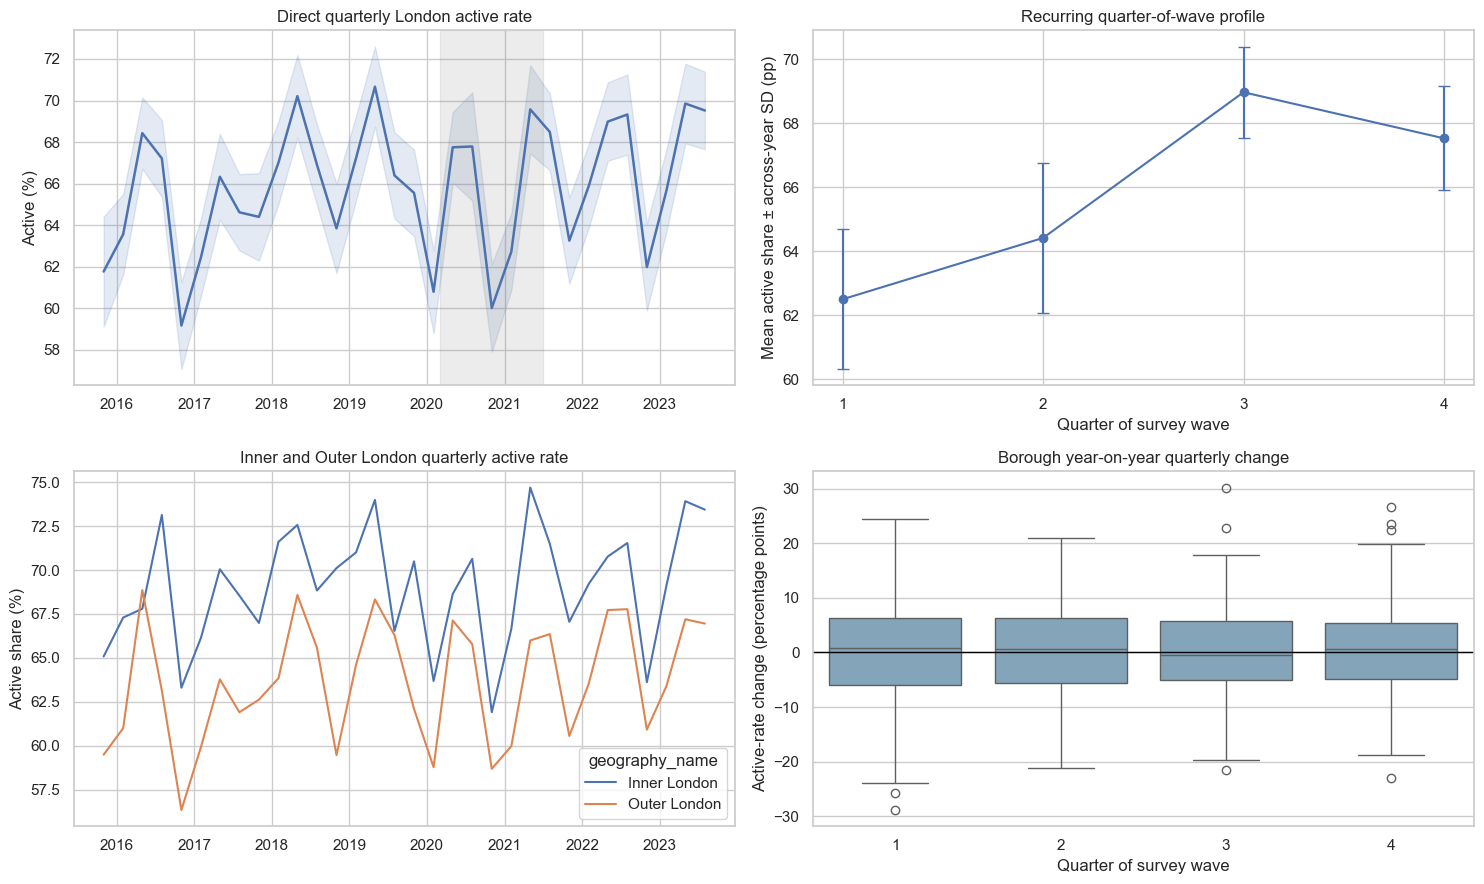

In [8]:
london_quarterly_ci = add_rate_uncertainty(london_quarterly)
borough_quarterly_analysis = add_rate_uncertainty(borough_quarterly).sort_values(
    ['geography_code', 'quarter_index']
)
borough_quarterly_analysis['active_yoy_change_pp'] = (
    borough_quarterly_analysis.groupby('geography_code')['active_rate'].diff(4) * 100
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
x = london_quarterly_ci['quarter_start']
axes[0, 0].plot(x, london_quarterly_ci['active_rate'] * 100, color='#4c72b0', linewidth=1.8)
axes[0, 0].fill_between(
    x, london_quarterly_ci['active_rate_low'] * 100,
    london_quarterly_ci['active_rate_high'] * 100, color='#4c72b0', alpha=.15,
)
axes[0, 0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.15)
axes[0, 0].set(title='Direct quarterly London active rate', xlabel='', ylabel='Active (%)')

seasonal_quarter = london_quarterly.groupby('quarter_of_wave', as_index=False).agg(
    mean_active=('active_rate', 'mean'), sd_active=('active_rate', 'std')
)
axes[0, 1].errorbar(
    seasonal_quarter['quarter_of_wave'], seasonal_quarter['mean_active'] * 100,
    yerr=seasonal_quarter['sd_active'] * 100, marker='o', capsize=4, color='#4c72b0',
)
axes[0, 1].set_xticks([1, 2, 3, 4])
axes[0, 1].set(title='Recurring quarter-of-wave profile', xlabel='Quarter of survey wave',
               ylabel='Mean active share ± across-year SD (pp)')

area_quarterly_plot = area_quarterly.assign(active_pct=area_quarterly['active_rate'] * 100)
sns.lineplot(data=area_quarterly_plot, x='quarter_start', y='active_pct', hue='geography_name',
             estimator=None, linewidth=1.5, ax=axes[1, 0])
axes[1, 0].set(title='Inner and Outer London quarterly active rate', xlabel='', ylabel='Active share (%)')

sns.boxplot(data=borough_quarterly_analysis.dropna(subset=['active_yoy_change_pp']),
            x='quarter_of_wave', y='active_yoy_change_pp', color='#7aa6c2', ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set(title='Borough year-on-year quarterly change', xlabel='Quarter of survey wave',
               ylabel='Active-rate change (percentage points)')
fig.tight_layout()
save_figure(fig, 'quarterly_activity_patterns.png')
plt.show()


### Findings

Quarterly pooling reveals recurring within-year movement while reducing borough noise relative to
monthly estimates. Mean London active participation rises from about **62.5% in Quarter 1** to
**69.0% in Quarter 3**, although this is a repeated seasonal description rather than a causal
effect. Borough year-on-year change remains widely dispersed.


## 5. Spatial description of borough activity

GLA borough polygons are joined by GSS code. Choropleths show the Year 8 level and Year 1–8 change;
queen-contiguity Moran's I tests whether similar values are spatially adjacent. City of London is
excluded because the survey analysis consistently covers the other 32 boroughs.


,measure,morans_i,random_expectation,permutation_p_value
0,Year 8 active share,0.358717,-0.032258,0.001
1,Year 1–8 change,0.272881,-0.032258,0.005


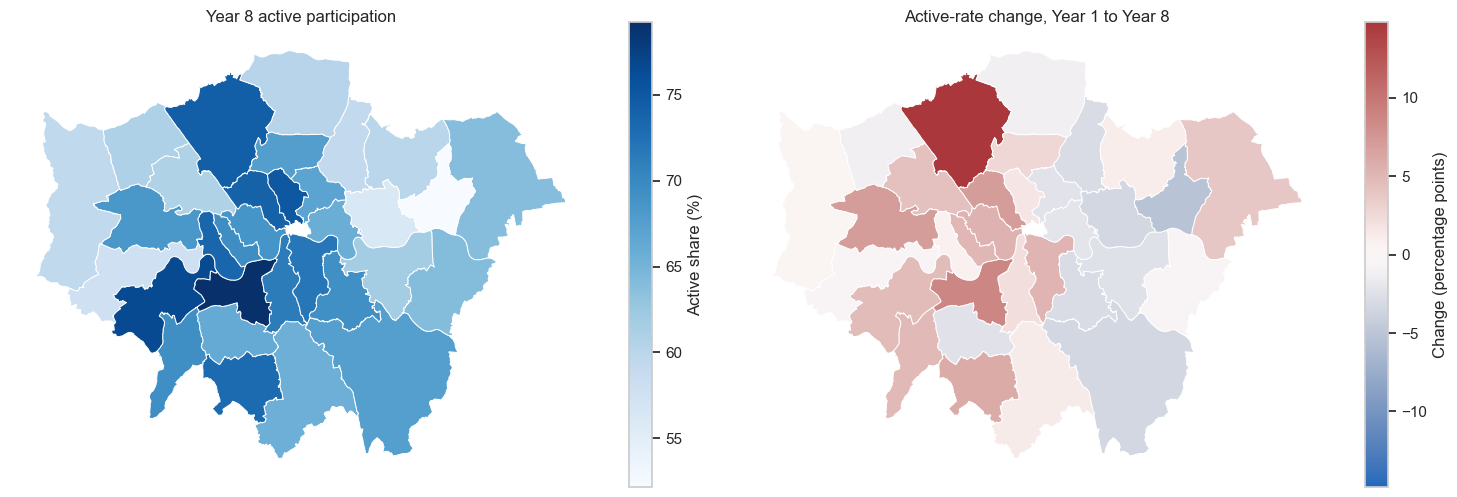

In [9]:
assert BOUNDARY_PATH.exists(), 'GLA borough boundary file is required for the spatial section'
borough_boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'name', 'geometry']]
spatial_values = latest[['geography_code', 'geography_name', 'active_rate']].merge(
    borough_change[['geography_code', 'change_pp']], on='geography_code', validate='one_to_one'
)
borough_map = borough_boundaries.merge(
    spatial_values, left_on='gss_code', right_on='geography_code', validate='one_to_one'
)
assert len(borough_map) == 32

geometries = borough_map.geometry.reset_index(drop=True)
n_boroughs = len(borough_map)
spatial_weights = np.zeros((n_boroughs, n_boroughs), dtype=float)
for i in range(n_boroughs):
    for j in range(i + 1, n_boroughs):
        if geometries.iloc[i].touches(geometries.iloc[j]):
            spatial_weights[i, j] = spatial_weights[j, i] = 1
assert spatial_weights.sum(axis=1).min() > 0


def moran_permutation(values, weights, repeats=999):
    values = np.asarray(values, dtype=float)
    centred = values - values.mean()
    observed = len(values) / weights.sum() * (centred @ weights @ centred) / (centred @ centred)
    expected = -1 / (len(values) - 1)
    rng = np.random.default_rng(RANDOM_STATE + len(values))
    permuted = []
    for _ in range(repeats):
        shuffled = rng.permutation(centred)
        permuted.append(len(values) / weights.sum() * (shuffled @ weights @ shuffled) /
                        (shuffled @ shuffled))
    permuted = np.asarray(permuted)
    p_value = (1 + np.sum(np.abs(permuted - expected) >= abs(observed - expected))) / (repeats + 1)
    return observed, expected, p_value


spatial_rows = []
for variable, label in [('active_rate', 'Year 8 active share'), ('change_pp', 'Year 1–8 change')]:
    statistic, expectation, p_value = moran_permutation(borough_map[variable], spatial_weights)
    spatial_rows.append({'measure': label, 'morans_i': statistic,
                         'random_expectation': expectation, 'permutation_p_value': p_value})
spatial_diagnostics = pd.DataFrame(spatial_rows)
display(spatial_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
borough_map.assign(active_pct=borough_map['active_rate'] * 100).plot(
    column='active_pct', cmap='Blues', edgecolor='white', linewidth=.7, legend=True, ax=axes[0],
    legend_kwds={'label': 'Active share (%)', 'shrink': .7},
)
axes[0].set_title('Year 8 active participation')
borough_map.plot(
    column='change_pp', cmap='vlag', edgecolor='white', linewidth=.7, legend=True, ax=axes[1],
    vmin=-borough_map['change_pp'].abs().max(), vmax=borough_map['change_pp'].abs().max(),
    legend_kwds={'label': 'Change (percentage points)', 'shrink': .7},
)
axes[1].set_title('Active-rate change, Year 1 to Year 8')
for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
save_figure(fig, 'borough_spatial_activity_patterns.png')
plt.show()


### Findings

The maps reveal where high and low values occur rather than reducing geography to Inner/Outer
labels. Spatial autocorrelation is positive for both the Year 8 level (**Moran's I = 0.359,
p = 0.001**) and Year 1–8 change (**I = 0.273, p = 0.005**), based on 999 permutations. These are
descriptive spatial patterns, not evidence of neighbourhood spillovers.


## 6. External context: between-borough and within-borough associations

Pooled correlations confound persistent place differences with change over time. Between-borough
Spearman correlations use eight-year borough means. Within-borough correlations use two-way
demeaned values, removing borough means and common year effects. Earnings are expressed relative
to the London adult-population-weighted mean to avoid treating nominal growth as a local advantage.


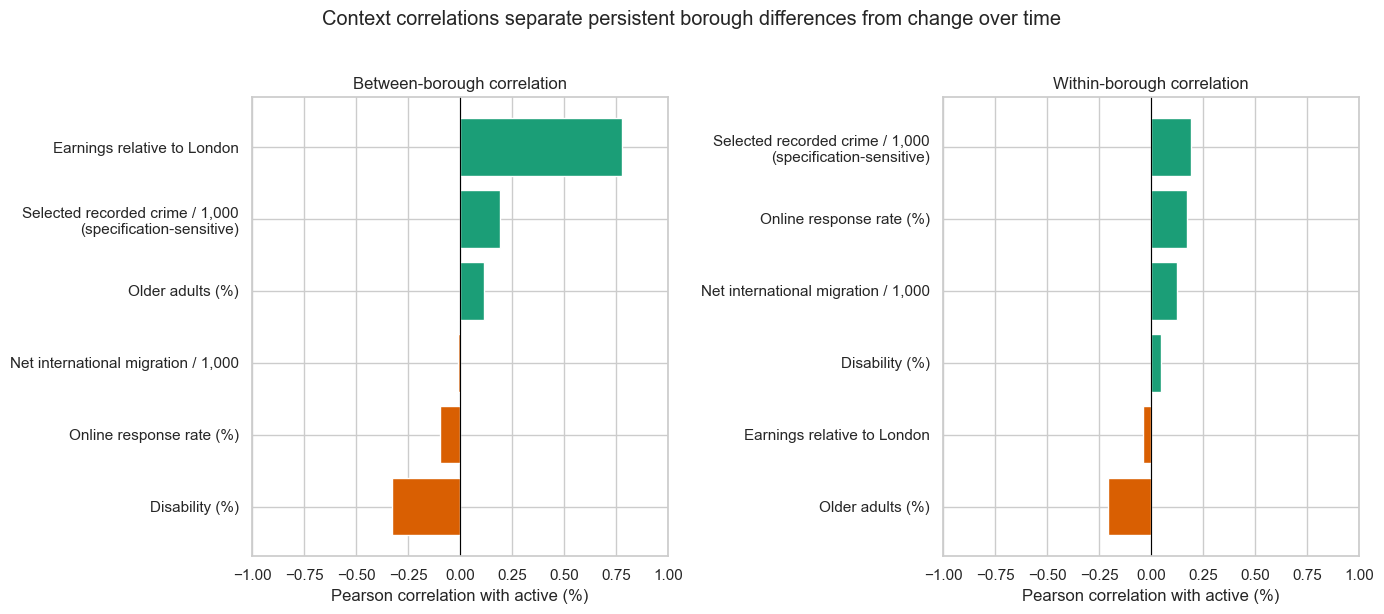

,variable,label,correlation_between,n_boroughs,correlation_within,n_observations
0,earnings_relative_to_london,Earnings relative to London,0.780,32,-0.041,256
1,selected_recorded_crime_rate_per_1000,"Selected recorded crime / 1,000\n(specificatio...",0.194,32,0.191,256
2,net_migration_per_1000,"Net international migration / 1,000",-0.011,32,0.122,256
3,limiting_disability_rate,Disability (%),-0.327,32,0.048,256
4,older_adult_rate,Older adults (%),0.116,32,-0.206,256
5,online_response_rate,Online response rate (%),-0.095,32,0.174,256


In [10]:
borough_annual['active_pct'] = borough_annual['active_rate'] * 100
context_labels = {
    'earnings_relative_to_london': 'Earnings relative to London',
    'selected_recorded_crime_rate_per_1000': 'Selected recorded crime / 1,000\n(specification-sensitive)',
    'net_migration_per_1000': 'Net international migration / 1,000',
    'limiting_disability_rate': 'Disability (%)',
    'older_adult_rate': 'Older adults (%)',
    'online_response_rate': 'Online response rate (%)',
}
context_vars = list(context_labels)

between_rows, within_rows = [], []
for variable in context_vars:
    between = borough_annual.groupby('geography_code').agg(
        active_pct=('active_pct', 'mean'),
        context=(variable, 'mean'),
    ).dropna()
    within = borough_annual[['geography_code', 'active_pct', variable]].dropna().copy()
    within['active_dm'] = within['active_pct'] - within.groupby('geography_code')['active_pct'].transform('mean')
    within['context_dm'] = within[variable] - within.groupby('geography_code')[variable].transform('mean')
    between_rows.append({
        'variable': variable,
        'label': context_labels[variable],
        'correlation': between['active_pct'].corr(between['context']),
        'n_boroughs': len(between),
    })
    within_rows.append({
        'variable': variable,
        'label': context_labels[variable],
        'correlation': within['active_dm'].corr(within['context_dm']),
        'n_observations': len(within),
    })

between_correlations = pd.DataFrame(between_rows)
within_correlations = pd.DataFrame(within_rows)
correlation_comparison = between_correlations.merge(
    within_correlations, on=['variable', 'label'], suffixes=('_between', '_within')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, frame, title in zip(
    axes,
    [between_correlations, within_correlations],
    ['Between-borough correlation', 'Within-borough correlation'],
):
    ordered = frame.sort_values('correlation')
    colours = np.where(ordered['correlation'] >= 0, '#1b9e77', '#d95f02')
    ax.barh(ordered['label'], ordered['correlation'], color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(title)
    ax.set_xlabel('Pearson correlation with active (%)')
fig.suptitle('Context correlations separate persistent borough differences from change over time', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'between_within_correlations.png', dpi=180, bbox_inches='tight')
plt.show()

display(correlation_comparison.round(3))

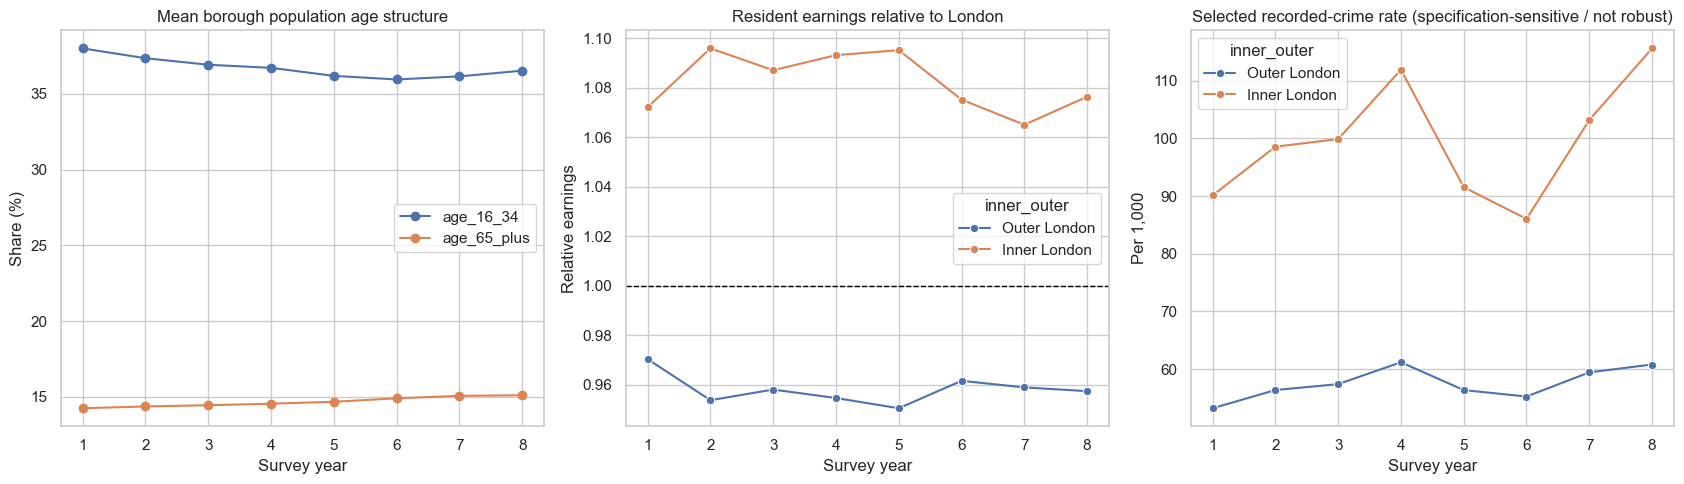

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
population_trend = borough_annual.groupby('year', as_index=False).agg(
    age_16_34=('population_age_16_34_rate', 'mean'),
    age_65_plus=('population_age_65_plus_rate', 'mean'),
)
population_trend.set_index('year').mul(100).plot(marker='o', ax=axes[0])
axes[0].set(title='Mean borough population age structure', xlabel='Survey year', ylabel='Share (%)')

sns.lineplot(data=borough_annual, x='year', y='earnings_relative_to_london',
             hue='inner_outer', marker='o', errorbar=None, ax=axes[1])
axes[1].axhline(1, color='black', linewidth=1, linestyle='--')
axes[1].set(title='Resident earnings relative to London', xlabel='Survey year', ylabel='Relative earnings')

sns.lineplot(data=borough_annual, x='year', y='selected_recorded_crime_rate_per_1000',
             hue='inner_outer', marker='o', errorbar=None, ax=axes[2])
axes[2].set(title='Selected recorded-crime rate (specification-sensitive / not robust)', xlabel='Survey year', ylabel='Per 1,000')
fig.tight_layout()
save_figure(fig, 'external_context_over_time.png')
plt.show()


### Findings

Several strong between-borough patterns almost disappear after persistent borough differences and
common year movements are removed. Relative earnings correlate **0.80** with borough mean active
share but only **−0.05** with two-way-demeaned active share. The separated table should therefore
replace one pooled correlation matrix; neither column identifies contextual effects.


## 7. Population composition and age-specific participation

Age-specific survey rates are aligned to ONS adult population shares for 16–34, 35–54, 55–64 and
65+. Symmetric decomposition is applied to London, Inner/Outer London and every borough. Approximate
Monte Carlo intervals propagate uncertainty in the age-specific survey rates while treating ONS
population shares as fixed.


,geography_level,age_band,median,min
0,Borough,16-34,81.748186,37.899755
1,Borough,35-54,118.335322,64.234214
2,Borough,55-64,45.517610,17.586770
3,Borough,65+,69.470319,10.549237
4,Inner/Outer,16-34,1316.636588,1181.943462
5,Inner/Outer,35-54,1758.784867,1271.820059
6,Inner/Outer,55-64,694.611741,413.133154
7,Inner/Outer,65+,976.982616,486.300247
8,London,16-34,2609.155332,2429.374010
9,London,35-54,3560.946704,3308.615178


,geography_level,geographies,median_absolute_reconstruction_gap_pp,mean_composition_effect_pp,mean_within_age_group_effect_pp
0,Borough,32,0.531651,-0.272290,2.008025
1,Inner/Outer,2,0.054458,-0.230043,2.070866
2,London,1,0.012585,-0.237909,2.056605


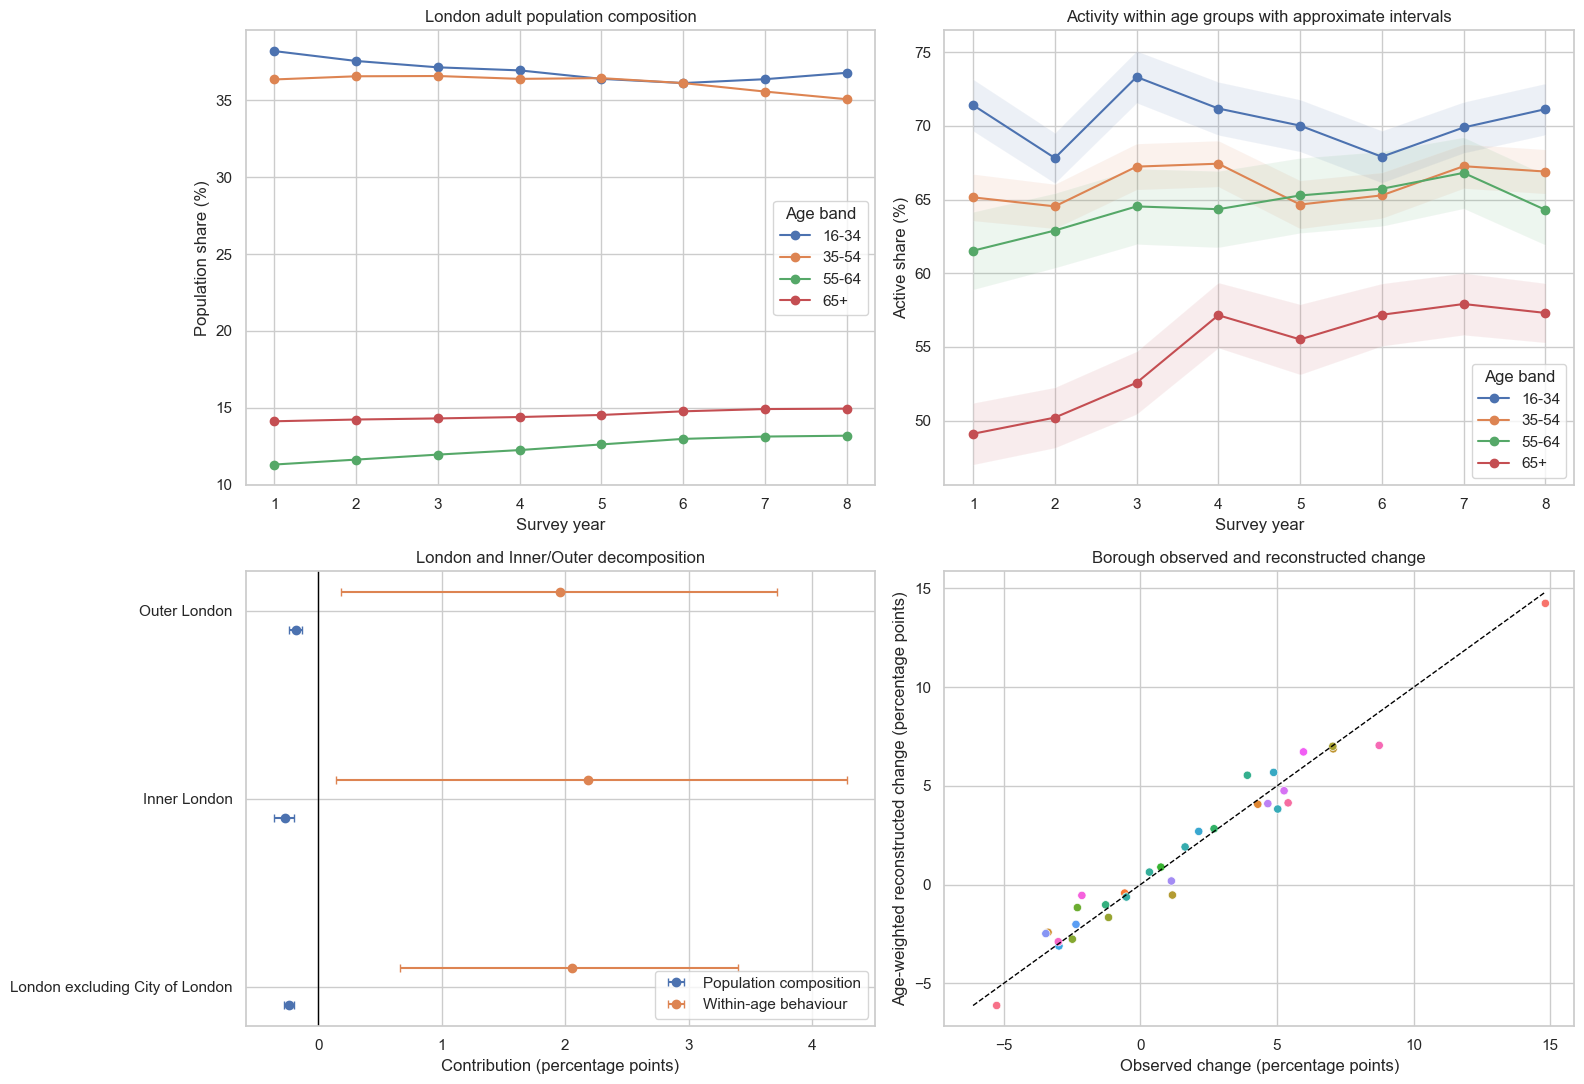

In [12]:
AGE_ORDER = ['16-34', '35-54', '55-64', '65+']


def symmetric_decomposition(start, end):
    start = start.set_index('age_band').reindex(AGE_ORDER)
    end = end.set_index('age_band').reindex(AGE_ORDER)
    assert start[['population_share', 'active_rate']].notna().all().all()
    assert end[['population_share', 'active_rate']].notna().all().all()
    w0, w1 = start['population_share'].to_numpy(), end['population_share'].to_numpy()
    r0, r1 = start['active_rate'].to_numpy(), end['active_rate'].to_numpy()
    composition = np.sum((w1 - w0) * (r0 + r1) / 2)
    within_group = np.sum((r1 - r0) * (w0 + w1) / 2)
    return composition, within_group, np.sum(w1 * r1) - np.sum(w0 * r0)


def decomposition_interval(start, end, seed, repeats=2000):
    start = start.set_index('age_band').reindex(AGE_ORDER)
    end = end.set_index('age_band').reindex(AGE_ORDER)
    rng = np.random.default_rng(seed)
    w0, w1 = start['population_share'].to_numpy(), end['population_share'].to_numpy()
    p0, p1 = start['active_rate'].to_numpy(), end['active_rate'].to_numpy()
    se0 = np.sqrt(p0 * (1 - p0) / start['effective_n'].to_numpy())
    se1 = np.sqrt(p1 * (1 - p1) / end['effective_n'].to_numpy())
    r0 = np.clip(rng.normal(p0, se0, size=(repeats, len(p0))), 0, 1)
    r1 = np.clip(rng.normal(p1, se1, size=(repeats, len(p1))), 0, 1)
    composition = ((w1 - w0) * (r0 + r1) / 2).sum(axis=1)
    within = ((r1 - r0) * (w0 + w1) / 2).sum(axis=1)
    return (*np.quantile(composition, [.025, .975]), *np.quantile(within, [.025, .975]))


def decompose_age_level(age_frame, annual_frame, level, seed_offset):
    rows = []
    for position, (code_value, group) in enumerate(age_frame.groupby('geography_code')):
        start, end = group.loc[group['year'].eq(1)], group.loc[group['year'].eq(8)]
        composition, within_group, reconstructed = symmetric_decomposition(start, end)
        observed_group = annual_frame.loc[annual_frame['geography_code'].eq(code_value)]
        observed = (observed_group.loc[observed_group['year'].eq(8), 'active_rate'].iloc[0]
                    - observed_group.loc[observed_group['year'].eq(1), 'active_rate'].iloc[0])
        comp_low, comp_high, within_low, within_high = decomposition_interval(
            start, end, RANDOM_STATE + seed_offset + position
        )
        rows.append({
            'geography_level': level, 'geography_code': code_value,
            'geography_name': group['geography_name'].iloc[0],
            'composition_effect': composition, 'composition_low': comp_low,
            'composition_high': comp_high, 'within_age_group_effect': within_group,
            'within_low': within_low, 'within_high': within_high,
            'reconstructed_change': reconstructed, 'observed_survey_change': observed,
            'reconstruction_gap': observed - reconstructed,
        })
    return pd.DataFrame(rows)


age_decomposition_all = pd.concat([
    decompose_age_level(age_london_annual, london_annual, 'London', 0),
    decompose_age_level(age_area_annual, area_annual, 'Inner/Outer', 100),
    decompose_age_level(age_borough_annual, borough_annual, 'Borough', 200),
], ignore_index=True)
age_decomposition = age_decomposition_all.loc[
    age_decomposition_all['geography_level'].eq('Borough')
].copy()
age_precision = pd.concat([
    age_london_annual.assign(geography_level='London'),
    age_area_annual.assign(geography_level='Inner/Outer'),
    age_borough_annual.assign(geography_level='Borough'),
]).groupby(['geography_level', 'age_band'])['effective_n'].agg(['median', 'min']).reset_index()
reconstruction_summary = age_decomposition_all.groupby('geography_level').agg(
    geographies=('geography_code', 'size'),
    median_absolute_reconstruction_gap_pp=('reconstruction_gap', lambda x: x.abs().median() * 100),
    mean_composition_effect_pp=('composition_effect', lambda x: x.mean() * 100),
    mean_within_age_group_effect_pp=('within_age_group_effect', lambda x: x.mean() * 100),
).reset_index()
display(age_precision)
display(reconstruction_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for age_band, group in age_london_annual.groupby('age_band'):
    group = group.sort_values('year')
    axes[0, 0].plot(group['year'], group['population_share'] * 100, marker='o', label=age_band)
axes[0, 0].set(title='London adult population composition', xlabel='Survey year', ylabel='Population share (%)')
axes[0, 0].legend(title='Age band')

for age_band, group in age_london_annual.groupby('age_band'):
    group = group.sort_values('year')
    se = np.sqrt(group['active_rate'] * (1 - group['active_rate']) / group['effective_n'])
    axes[0, 1].plot(group['year'], group['active_rate'] * 100, marker='o', label=age_band)
    axes[0, 1].fill_between(group['year'], (group['active_rate'] - 1.96 * se).clip(0, 1) * 100,
                            (group['active_rate'] + 1.96 * se).clip(0, 1) * 100, alpha=.10)
axes[0, 1].set(title='Activity within age groups with approximate intervals',
               xlabel='Survey year', ylabel='Active share (%)')
axes[0, 1].legend(title='Age band')

headline = age_decomposition_all.loc[~age_decomposition_all['geography_level'].eq('Borough')].copy()
y = np.arange(len(headline))
axes[1, 0].errorbar(headline['composition_effect'] * 100, y - .10,
                    xerr=np.vstack([(headline['composition_effect'] - headline['composition_low']) * 100,
                                    (headline['composition_high'] - headline['composition_effect']) * 100]),
                    fmt='o', capsize=3, label='Population composition')
axes[1, 0].errorbar(headline['within_age_group_effect'] * 100, y + .10,
                    xerr=np.vstack([(headline['within_age_group_effect'] - headline['within_low']) * 100,
                                    (headline['within_high'] - headline['within_age_group_effect']) * 100]),
                    fmt='o', capsize=3, label='Within-age behaviour')
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_yticks(y, headline['geography_name'])
axes[1, 0].set(title='London and Inner/Outer decomposition', xlabel='Contribution (percentage points)')
axes[1, 0].legend()

age_decomposition_plot = age_decomposition.assign(
    observed_change_pp=age_decomposition['observed_survey_change'] * 100,
    reconstructed_change_pp=age_decomposition['reconstructed_change'] * 100,
)
sns.scatterplot(data=age_decomposition_plot, x='observed_change_pp', y='reconstructed_change_pp',
                hue='geography_name', legend=False, ax=axes[1, 1])
limits = np.array([
    age_decomposition_plot[['observed_change_pp', 'reconstructed_change_pp']].min().min(),
    age_decomposition_plot[['observed_change_pp', 'reconstructed_change_pp']].max().max(),
])
axes[1, 1].plot(limits, limits, color='black', linestyle='--', linewidth=1)
axes[1, 1].set(title='Borough observed and reconstructed change',
               xlabel='Observed change (percentage points)',
               ylabel='Age-weighted reconstructed change (percentage points)')
fig.tight_layout()
save_figure(fig, 'age_composition_participation_and_decomposition.png')
plt.show()


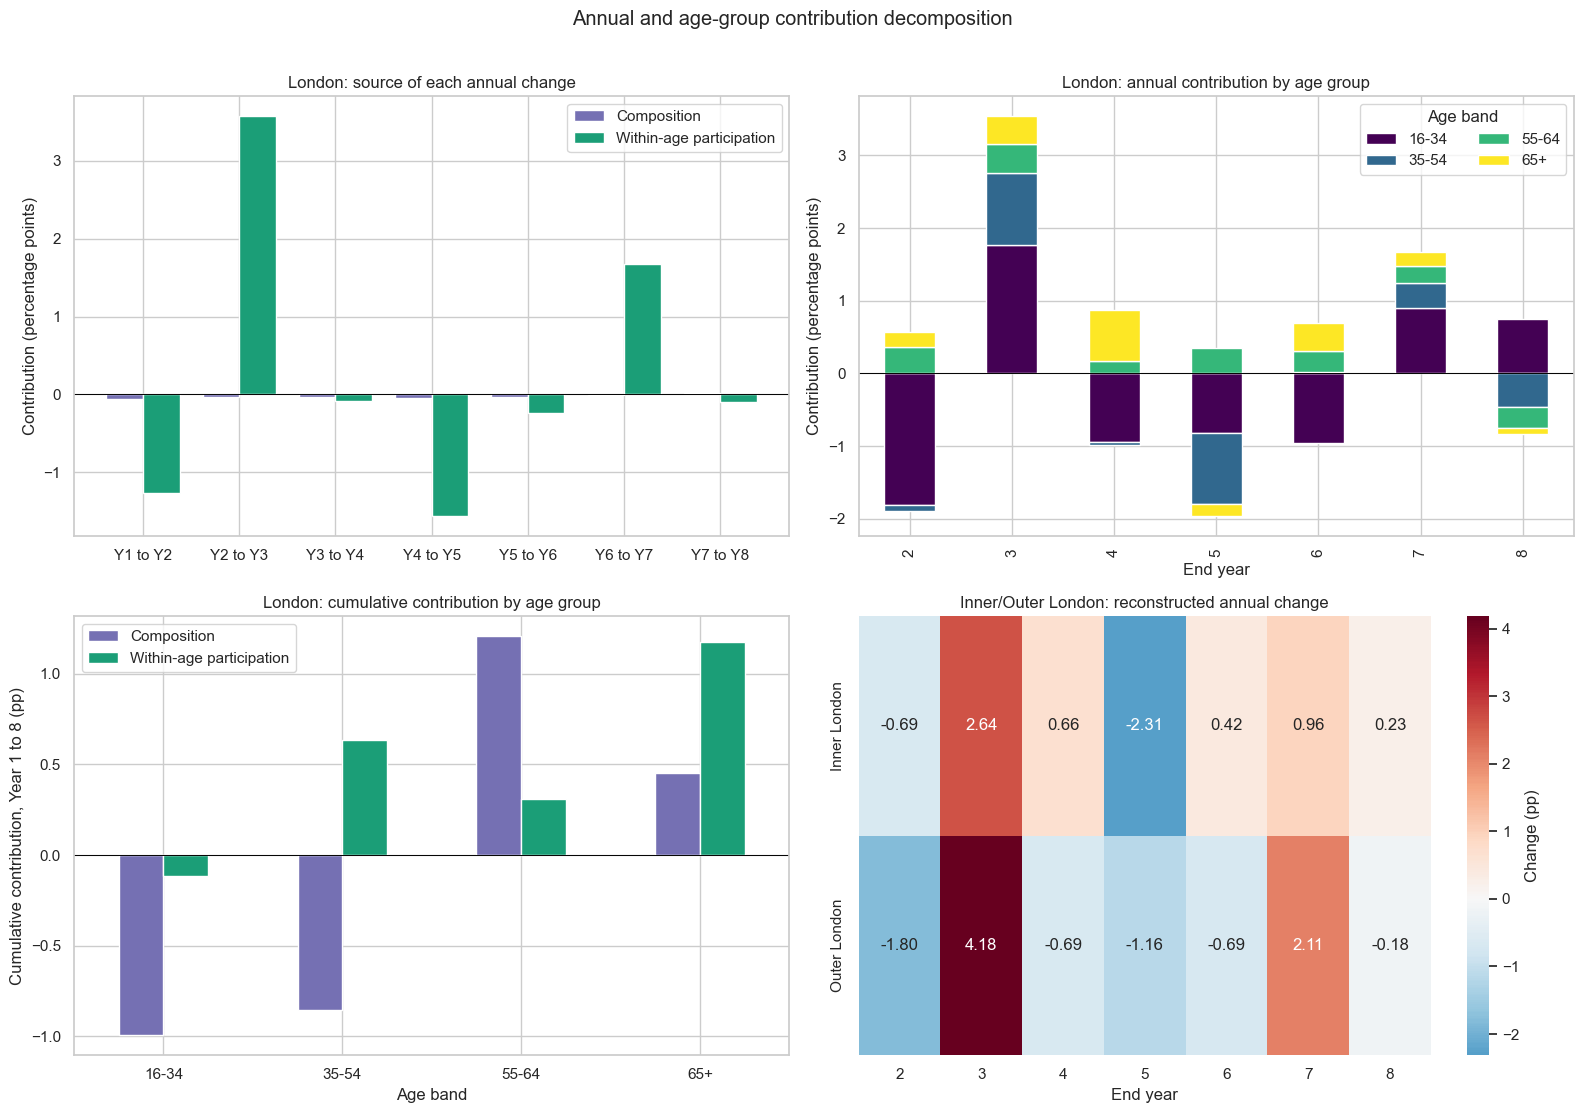

,geography_level,geography_code,geography_name,start_year,end_year,composition_contribution_pp,within_age_contribution_pp,reconstructed_change_pp,published_change_pp,reconstruction_error_pp
238,London,LONDON_32,London excluding City of London,1,2,-0.057,-1.269,-1.325,-1.325,0.0
239,London,LONDON_32,London excluding City of London,2,3,-0.037,3.572,3.536,3.536,-0.0
240,London,LONDON_32,London excluding City of London,3,4,-0.030,-0.085,-0.115,-0.115,-0.0
241,London,LONDON_32,London excluding City of London,4,5,-0.043,-1.558,-1.601,-1.601,-0.0
242,London,LONDON_32,London excluding City of London,5,6,-0.029,-0.237,-0.266,-0.266,0.0
243,London,LONDON_32,London excluding City of London,6,7,-0.006,1.679,1.673,1.673,0.0
244,London,LONDON_32,London excluding City of London,7,8,0.011,-0.094,-0.083,-0.083,-0.0


,age_band,composition_contribution_pp,within_age_contribution_pp,total_contribution_pp
0,16-34,-0.995,-0.115,-1.110
1,35-54,-0.857,0.634,-0.222
2,55-64,1.209,0.312,1.520
3,65+,0.452,1.178,1.630


In [13]:
# Exact transition-by-transition age decomposition for every geography.
# Contributions are percentage points. The symmetric formula splits interaction
# terms evenly and reconstructs each age-standardised transition exactly.
age_panel_all = pd.concat([
    age_london_annual.assign(geography_level='London'),
    age_area_annual.assign(geography_level='InnerOuter'),
    age_borough_annual.assign(geography_level='Borough'),
], ignore_index=True)

age_annual_rows = []
for (level, code, name), group in age_panel_all.groupby(
    ['geography_level', 'geography_code', 'geography_name'], dropna=False
):
    group = group.sort_values(['year', 'age_band'])
    years = sorted(group['year'].unique())
    for start_year, end_year in zip(years[:-1], years[1:]):
        start = group.loc[group['year'].eq(start_year)].set_index('age_band')
        end = group.loc[group['year'].eq(end_year)].set_index('age_band')
        common = [band for band in AGE_ORDER if band in start.index and band in end.index]
        if len(common) != len(AGE_ORDER):
            continue
        for age_band in common:
            w0, w1 = start.at[age_band, 'population_share'], end.at[age_band, 'population_share']
            r0, r1 = start.at[age_band, 'active_rate'], end.at[age_band, 'active_rate']
            composition = (w1 - w0) * (r0 + r1) / 2 * 100
            within = (r1 - r0) * (w0 + w1) / 2 * 100
            age_annual_rows.append({
                'geography_level': level,
                'geography_code': code,
                'geography_name': name,
                'start_year': int(start_year),
                'end_year': int(end_year),
                'age_band': age_band,
                'composition_contribution_pp': composition,
                'within_age_contribution_pp': within,
                'total_contribution_pp': composition + within,
            })

age_annual_contributions = pd.DataFrame(age_annual_rows)
age_annual_totals = age_annual_contributions.groupby(
    ['geography_level', 'geography_code', 'geography_name', 'start_year', 'end_year'],
    as_index=False,
).agg(
    composition_contribution_pp=('composition_contribution_pp', 'sum'),
    within_age_contribution_pp=('within_age_contribution_pp', 'sum'),
    reconstructed_change_pp=('total_contribution_pp', 'sum'),
)

age_weighted = age_panel_all.assign(
    weighted_active_component=lambda x: x['population_share'] * x['active_rate'] * 100
).groupby(
    ['geography_level', 'geography_code', 'geography_name', 'year'], as_index=False
).agg(age_standardised_active_pct=('weighted_active_component', 'sum'))
age_weighted['published_change_pp'] = age_weighted.groupby(
    ['geography_level', 'geography_code', 'geography_name']
)['age_standardised_active_pct'].diff()
age_annual_totals = age_annual_totals.merge(
    age_weighted[['geography_level', 'geography_code', 'geography_name', 'year', 'published_change_pp']],
    left_on=['geography_level', 'geography_code', 'geography_name', 'end_year'],
    right_on=['geography_level', 'geography_code', 'geography_name', 'year'],
    how='left',
).drop(columns='year')
age_annual_totals['reconstruction_error_pp'] = (
    age_annual_totals['reconstructed_change_pp'] - age_annual_totals['published_change_pp']
)
assert len(age_annual_contributions) == (1 + 2 + 32) * 7 * 4
assert age_annual_totals['reconstruction_error_pp'].abs().max() < 1e-9

london_age_annual = age_annual_contributions.loc[
    age_annual_contributions['geography_level'].eq('London')
].copy()
london_age_totals = age_annual_totals.loc[
    age_annual_totals['geography_level'].eq('London')
].copy()
london_age_cumulative = london_age_annual.groupby('age_band', as_index=False).agg(
    composition_contribution_pp=('composition_contribution_pp', 'sum'),
    within_age_contribution_pp=('within_age_contribution_pp', 'sum'),
    total_contribution_pp=('total_contribution_pp', 'sum'),
)
london_age_cumulative['age_band'] = pd.Categorical(
    london_age_cumulative['age_band'], categories=AGE_ORDER, ordered=True
)
london_age_cumulative = london_age_cumulative.sort_values('age_band')

area_age_totals = age_annual_totals.loc[
    age_annual_totals['geography_level'].eq('InnerOuter')
].copy()
area_heat = area_age_totals.pivot(
    index='geography_name', columns='end_year', values='reconstructed_change_pp'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
x = np.arange(len(london_age_totals))
width = 0.38
axes[0, 0].bar(x - width / 2, london_age_totals['composition_contribution_pp'], width,
               label='Composition', color='#7570b3')
axes[0, 0].bar(x + width / 2, london_age_totals['within_age_contribution_pp'], width,
               label='Within-age participation', color='#1b9e77')
axes[0, 0].axhline(0, color='black', linewidth=0.7)
axes[0, 0].set_xticks(x, [f"Y{a} to Y{b}" for a, b in zip(london_age_totals['start_year'], london_age_totals['end_year'])])
axes[0, 0].set_ylabel('Contribution (percentage points)')
axes[0, 0].set_title('London: source of each annual change')
axes[0, 0].legend()

annual_age_pivot = london_age_annual.pivot(
    index='end_year', columns='age_band', values='total_contribution_pp'
).reindex(columns=AGE_ORDER)
annual_age_pivot.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='viridis')
axes[0, 1].axhline(0, color='black', linewidth=0.7)
axes[0, 1].set_xlabel('End year')
axes[0, 1].set_ylabel('Contribution (percentage points)')
axes[0, 1].set_title('London: annual contribution by age group')
axes[0, 1].legend(title='Age band', ncol=2)

london_age_cumulative.set_index('age_band')[
    ['composition_contribution_pp', 'within_age_contribution_pp']
].rename(columns={
    'composition_contribution_pp': 'Composition',
    'within_age_contribution_pp': 'Within-age participation',
}).plot(kind='bar', ax=axes[1, 0], color=['#7570b3', '#1b9e77'])
axes[1, 0].axhline(0, color='black', linewidth=0.7)
axes[1, 0].set_xlabel('Age band')
axes[1, 0].set_ylabel('Cumulative contribution, Year 1 to 8 (pp)')
axes[1, 0].set_title('London: cumulative contribution by age group')
axes[1, 0].tick_params(axis='x', rotation=0)

sns.heatmap(area_heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1, 1],
            cbar_kws={'label': 'Change (pp)'})
axes[1, 1].set_xlabel('End year')
axes[1, 1].set_ylabel('')
axes[1, 1].set_title('Inner/Outer London: reconstructed annual change')

fig.suptitle('Annual and age-group contribution decomposition', y=1.01)
fig.tight_layout()
save_figure(fig, 'age_annual_and_age_group_contributions.png')
plt.show()

display(london_age_totals.round(3))
display(london_age_cumulative.round(3))

### Findings

The endpoint decomposition still covers London, Inner/Outer London and all 32 boroughs, with age-cell precision and approximate uncertainty. It is now supplemented by an exact annual decomposition: **980 age-group contribution rows** cover 35 geographies, seven adjacent-year transitions and four age groups, and every transition reconstructs the age-standardised change to numerical precision.

For London over Year 1 to Year 8, changing population shares contribute **-0.19 percentage points** and changing participation within age groups contributes **+2.01 points**, reconstructing **+1.82 points**. By age group, the cumulative total contributions are **-1.11** (16-34), **-0.22** (35-54), **+1.52** (55-64) and **+1.63** (65+) percentage points. The transition chart also shows that the net rise is not smooth: within-age changes alternate in sign across years. These are accounting contributions, not causal effects.

## 8. Same time, different boroughs—and the same borough over time

The primary descriptive models use substantive demographic, income, migration, disability and recorded-crime covariates. `online_response_rate` is deliberately excluded from the primary specification: it is a survey-mode diagnostic and is added only in explicitly labelled sensitivity models.

The pooled cross-sectional model includes year effects **and an explicit Inner/Outer London control**, so its borough contrasts do not simply reproduce that broad geography split. The borough fixed-effects model does not add Inner/Outer separately because the classification is time-invariant and is therefore perfectly absorbed by borough effects. For the same reason, Inner/Outer drops out algebraically in first differences.

All three estimators remain descriptive rather than causal. The table and figures distinguish the primary estimates from the online-response sensitivity check, report two-way-demeaned VIFs, and include residual, influence and clustered-inference diagnostics.

In [14]:
analysis = borough_annual.copy()
analysis['active_pct'] = analysis['active_rate'] * 100
analysis['weight'] = analysis['effective_n'].clip(lower=1)

PRIMARY_RAW_FEATURES = [
    'population_age_16_34_rate',
    'population_age_65_plus_rate',
    'population_female_rate',
    'net_migration_per_1000',
    'earnings_relative_to_london',
    'selected_recorded_crime_rate_per_1000',
    'older_adult_rate',
    'limiting_disability_rate',
]
SENSITIVITY_FEATURE = 'online_response_rate'
ALL_MODEL_FEATURES = PRIMARY_RAW_FEATURES + [SENSITIVITY_FEATURE]
FEATURE_LABELS = {
    'population_age_16_34_rate': 'Population aged 16–34',
    'population_age_65_plus_rate': 'Population aged 65+',
    'population_female_rate': 'Female population',
    'net_migration_per_1000': 'Net international migration',
    'earnings_relative_to_london': 'Earnings relative to London',
    'selected_recorded_crime_rate_per_1000': 'Selected crime / 1,000\n(specification-sensitive / not robust)',
    'older_adult_rate': 'Older adults in survey',
    'limiting_disability_rate': 'Disabled respondents',
    'online_response_rate': 'Online response rate (sensitivity only)',
}

standardisation = {}
for feature in ALL_MODEL_FEATURES:
    mean = analysis[feature].mean()
    std = analysis[feature].std(ddof=0)
    standardisation[feature] = {'mean': mean, 'std': std}
    analysis[f'z_{feature}'] = (analysis[feature] - mean) / std

PRIMARY_STANDARD_FEATURES = [f'z_{feature}' for feature in PRIMARY_RAW_FEATURES]
ONLINE_STANDARD_FEATURE = f'z_{SENSITIVITY_FEATURE}'
ALL_STANDARD_FEATURES = PRIMARY_STANDARD_FEATURES + [ONLINE_STANDARD_FEATURE]
primary_rhs = ' + '.join(PRIMARY_STANDARD_FEATURES)
sensitivity_rhs = primary_rhs + f' + {ONLINE_STANDARD_FEATURE}'

pooled_formula = f'active_pct ~ {primary_rhs} + C(year) + C(inner_outer)'
fixed_effects_formula = f'active_pct ~ {primary_rhs} + C(year) + C(geography_code)'
pooled_sensitivity_formula = f'active_pct ~ {sensitivity_rhs} + C(year) + C(inner_outer)'
fixed_effects_sensitivity_formula = f'active_pct ~ {sensitivity_rhs} + C(year) + C(geography_code)'

pooled_model = smf.wls(pooled_formula, data=analysis, weights=analysis['weight']).fit(
    cov_type='cluster', cov_kwds={'groups': analysis['geography_code']}
)
fixed_effects_model = smf.wls(fixed_effects_formula, data=analysis, weights=analysis['weight']).fit(
    cov_type='cluster', cov_kwds={'groups': analysis['geography_code']}
)
pooled_sensitivity_model = smf.wls(
    pooled_sensitivity_formula, data=analysis, weights=analysis['weight']
).fit(cov_type='cluster', cov_kwds={'groups': analysis['geography_code']})
fixed_effects_sensitivity_model = smf.wls(
    fixed_effects_sensitivity_formula, data=analysis, weights=analysis['weight']
).fit(cov_type='cluster', cov_kwds={'groups': analysis['geography_code']})

difference = analysis.sort_values(['geography_code', 'year']).copy()
difference['d_active_pct'] = difference.groupby('geography_code')['active_pct'].diff()
for feature in ALL_STANDARD_FEATURES:
    difference[f'd_{feature}'] = difference.groupby('geography_code')[feature].diff()
difference['previous_effective_n'] = difference.groupby('geography_code')['effective_n'].shift()
# Inverse variance of a difference when each rate variance is proportional to 1/n.
difference['difference_weight'] = 1 / (
    1 / difference['effective_n'].clip(lower=1) + 1 / difference['previous_effective_n'].clip(lower=1)
)
difference = difference.dropna(subset=['d_active_pct'] + [f'd_{f}' for f in ALL_STANDARD_FEATURES])
primary_difference_features = [f'd_{f}' for f in PRIMARY_STANDARD_FEATURES]
online_difference_feature = f'd_{ONLINE_STANDARD_FEATURE}'
difference_formula = f"d_active_pct ~ {' + '.join(primary_difference_features)} + C(year)"
difference_sensitivity_formula = difference_formula.replace(
    ' + C(year)', f' + {online_difference_feature} + C(year)'
)
difference_model = smf.wls(
    difference_formula, data=difference, weights=difference['difference_weight']
).fit(cov_type='cluster', cov_kwds={'groups': difference['geography_code']})
difference_sensitivity_model = smf.wls(
    difference_sensitivity_formula, data=difference, weights=difference['difference_weight']
).fit(cov_type='cluster', cov_kwds={'groups': difference['geography_code']})

def coefficient_table(model, specification, terms, prefix=''):
    rows = []
    for raw_feature in terms:
        term = f'{prefix}z_{raw_feature}'
        rows.append({
            'specification': specification,
            'feature': raw_feature,
            'label': FEATURE_LABELS[raw_feature],
            'coefficient': model.params.get(term, np.nan),
            'standard_error': model.bse.get(term, np.nan),
            'p_value': model.pvalues.get(term, np.nan),
            'ci_low': model.conf_int().loc[term, 0] if term in model.params else np.nan,
            'ci_high': model.conf_int().loc[term, 1] if term in model.params else np.nan,
        })
    return pd.DataFrame(rows)

context_coefficients = pd.concat([
    coefficient_table(pooled_model, 'Year FE + Inner/Outer', PRIMARY_RAW_FEATURES),
    coefficient_table(fixed_effects_model, 'Borough + year FE', PRIMARY_RAW_FEATURES),
    coefficient_table(difference_model, 'First difference', PRIMARY_RAW_FEATURES, prefix='d_'),
], ignore_index=True)

online_sensitivity_coefficients = pd.concat([
    coefficient_table(pooled_sensitivity_model, 'Year FE + Inner/Outer + online', ALL_MODEL_FEATURES),
    coefficient_table(fixed_effects_sensitivity_model, 'Borough + year FE + online', ALL_MODEL_FEATURES),
    coefficient_table(difference_sensitivity_model, 'First difference + online', ALL_MODEL_FEATURES, prefix='d_'),
], ignore_index=True)

comparison_rows = []
for label, main_model, sensitivity_model, prefix in [
    ('Year FE + Inner/Outer', pooled_model, pooled_sensitivity_model, ''),
    ('Borough + year FE', fixed_effects_model, fixed_effects_sensitivity_model, ''),
    ('First difference', difference_model, difference_sensitivity_model, 'd_'),
]:
    online_term = f'{prefix}{ONLINE_STANDARD_FEATURE}'
    shifts = [
        abs(sensitivity_model.params[f'{prefix}z_{feature}'] - main_model.params[f'{prefix}z_{feature}'])
        for feature in PRIMARY_RAW_FEATURES
    ]
    comparison_rows.append({
        'specification': label,
        'online_coefficient': sensitivity_model.params[online_term],
        'online_standard_error': sensitivity_model.bse[online_term],
        'online_p_value': sensitivity_model.pvalues[online_term],
        'main_r_squared': main_model.rsquared,
        'online_adjusted_r_squared': sensitivity_model.rsquared,
        'r_squared_change': sensitivity_model.rsquared - main_model.rsquared,
        'maximum_absolute_primary_coefficient_shift': max(shifts),
    })
model_sensitivity_comparison = pd.DataFrame(comparison_rows)

def two_way_demean(frame, columns):
    out = frame[columns].copy()
    for column in columns:
        out[column] = (
            frame[column]
            - frame.groupby('geography_code')[column].transform('mean')
            - frame.groupby('year')[column].transform('mean')
            + frame[column].mean()
        )
    return out

def make_vif_table(features, model_role):
    demeaned = two_way_demean(analysis, features).dropna()
    return pd.DataFrame({
        'model_role': model_role,
        'feature': [feature.removeprefix('z_') for feature in features],
        'vif': [variance_inflation_factor(demeaned.values, i) for i in range(len(features))],
    })

within_vif = pd.concat([
    make_vif_table(PRIMARY_STANDARD_FEATURES, 'Primary model'),
    make_vif_table(ALL_STANDARD_FEATURES, 'Online-response sensitivity'),
], ignore_index=True)

def diagnostic_row(model, data, model_name):
    residuals = np.asarray(model.resid)
    fitted = np.asarray(model.fittedvalues)
    exog = np.asarray(model.model.exog)
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals, exog)
    influence = OLSInfluence(model)
    return {
        'model': model_name,
        'n_observations': int(model.nobs),
        'r_squared': model.rsquared,
        'adjusted_r_squared': model.rsquared_adj,
        'breusch_pagan_statistic': bp_stat,
        'breusch_pagan_p_value': bp_p,
        'residual_mean': residuals.mean(),
        'residual_sd': residuals.std(ddof=1),
        'maximum_absolute_studentised_residual': np.nanmax(np.abs(influence.resid_studentized_internal)),
        'maximum_cooks_distance': np.nanmax(influence.cooks_distance[0]),
    }

model_diagnostics = pd.DataFrame([
    diagnostic_row(pooled_model, analysis, 'Primary: year FE + Inner/Outer'),
    diagnostic_row(fixed_effects_model, analysis, 'Primary: borough + year FE'),
    diagnostic_row(difference_model, difference, 'Primary: first difference'),
    diagnostic_row(pooled_sensitivity_model, analysis, 'Sensitivity: year FE + Inner/Outer + online'),
    diagnostic_row(fixed_effects_sensitivity_model, analysis, 'Sensitivity: borough + year FE + online'),
    diagnostic_row(difference_sensitivity_model, difference, 'Sensitivity: first difference + online'),
])

diagnostic_headlines = pd.DataFrame([
    {'metric': 'Primary-model maximum two-way-demeaned VIF',
     'value': within_vif.loc[within_vif['model_role'].eq('Primary model'), 'vif'].max()},
    {'metric': 'Online-sensitivity maximum two-way-demeaned VIF',
     'value': within_vif.loc[within_vif['model_role'].eq('Online-response sensitivity'), 'vif'].max()},
    {'metric': 'Primary fixed-effects observations', 'value': fixed_effects_model.nobs},
    {'metric': 'Primary first-difference observations', 'value': difference_model.nobs},
])

display(context_coefficients.round(3))
display(model_sensitivity_comparison.round(3))
display(within_vif.round(3))
display(diagnostic_headlines.round(3))
display(model_diagnostics.round(3))

,specification,feature,label,coefficient,standard_error,p_value,ci_low,ci_high
0,Year FE + Inner/Outer,population_age_16_34_rate,Population aged 16–34,-1.444,1.397,0.301,-4.182,1.294
1,Year FE + Inner/Outer,population_age_65_plus_rate,Population aged 65+,0.230,1.543,0.882,-2.795,3.255
2,Year FE + Inner/Outer,population_female_rate,Female population,1.874,0.650,0.004,0.600,3.148
3,Year FE + Inner/Outer,net_migration_per_1000,Net international migration,-0.073,0.426,0.863,-0.909,0.762
4,Year FE + Inner/Outer,earnings_relative_to_london,Earnings relative to London,3.075,0.526,0.000,2.044,4.105
5,Year FE + Inner/Outer,selected_recorded_crime_rate_per_1000,"Selected crime / 1,000\n(specification-sensiti...",-0.561,0.436,0.198,-1.415,0.292
6,Year FE + Inner/Outer,older_adult_rate,Older adults in survey,-1.232,0.754,0.102,-2.710,0.246
7,Year FE + Inner/Outer,limiting_disability_rate,Disabled respondents,-0.814,0.310,0.009,-1.423,-0.206
8,Borough + year FE,population_age_16_34_rate,Population aged 16–34,0.683,3.342,0.838,-5.868,7.234
9,Borough + year FE,population_age_65_plus_rate,Population aged 65+,6.910,3.198,0.031,0.642,13.178


,specification,online_coefficient,online_standard_error,online_p_value,main_r_squared,online_adjusted_r_squared,r_squared_change,maximum_absolute_primary_coefficient_shift
0,Year FE + Inner/Outer,-0.232,0.618,0.708,0.620,0.620,0.000,0.039
1,Borough + year FE,-0.919,0.602,0.127,0.824,0.826,0.002,0.192
2,First difference,-1.980,0.619,0.001,0.226,0.274,0.048,1.766


,model_role,feature,vif
0,Primary model,population_age_16_34_rate,2.023
1,Primary model,population_age_65_plus_rate,1.605
2,Primary model,population_female_rate,1.540
3,Primary model,net_migration_per_1000,1.163
4,Primary model,earnings_relative_to_london,1.146
5,Primary model,selected_recorded_crime_rate_per_1000,1.134
6,Primary model,older_adult_rate,1.032
7,Primary model,limiting_disability_rate,1.063
8,Online-response sensitivity,population_age_16_34_rate,2.024
9,Online-response sensitivity,population_age_65_plus_rate,1.607


,metric,value
0,Primary-model maximum two-way-demeaned VIF,2.023
1,Online-sensitivity maximum two-way-demeaned VIF,2.024
2,Primary fixed-effects observations,256.000
3,Primary first-difference observations,224.000


,model,n_observations,r_squared,adjusted_r_squared,breusch_pagan_statistic,breusch_pagan_p_value,residual_mean,residual_sd,maximum_absolute_studentised_residual,maximum_cooks_distance
0,Primary: year FE + Inner/Outer,256,0.620,0.594,17.411,0.359,0.015,3.690,0.175,0.0
1,Primary: borough + year FE,256,0.824,0.785,58.964,0.095,-0.005,2.551,0.191,0.0
2,Primary: first difference,224,0.226,0.174,22.078,0.077,-0.018,3.872,0.275,0.0
3,Sensitivity: year FE + Inner/Outer + online,256,0.620,0.593,17.712,0.407,0.016,3.690,0.174,0.0
4,Sensitivity: borough + year FE + online,256,0.826,0.787,59.095,0.111,0.000,2.536,0.187,0.0
5,Sensitivity: first difference + online,224,0.274,0.221,23.185,0.080,-0.027,3.753,0.305,0.0


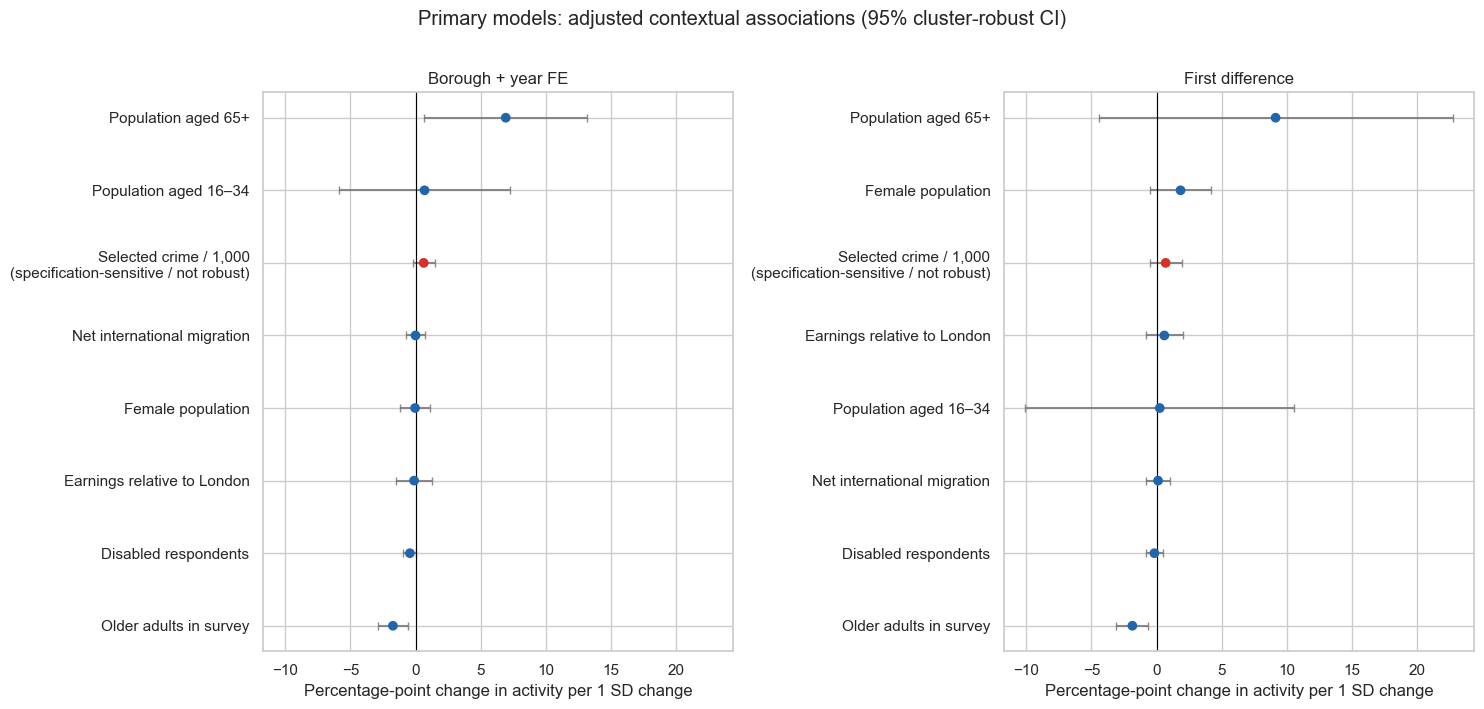

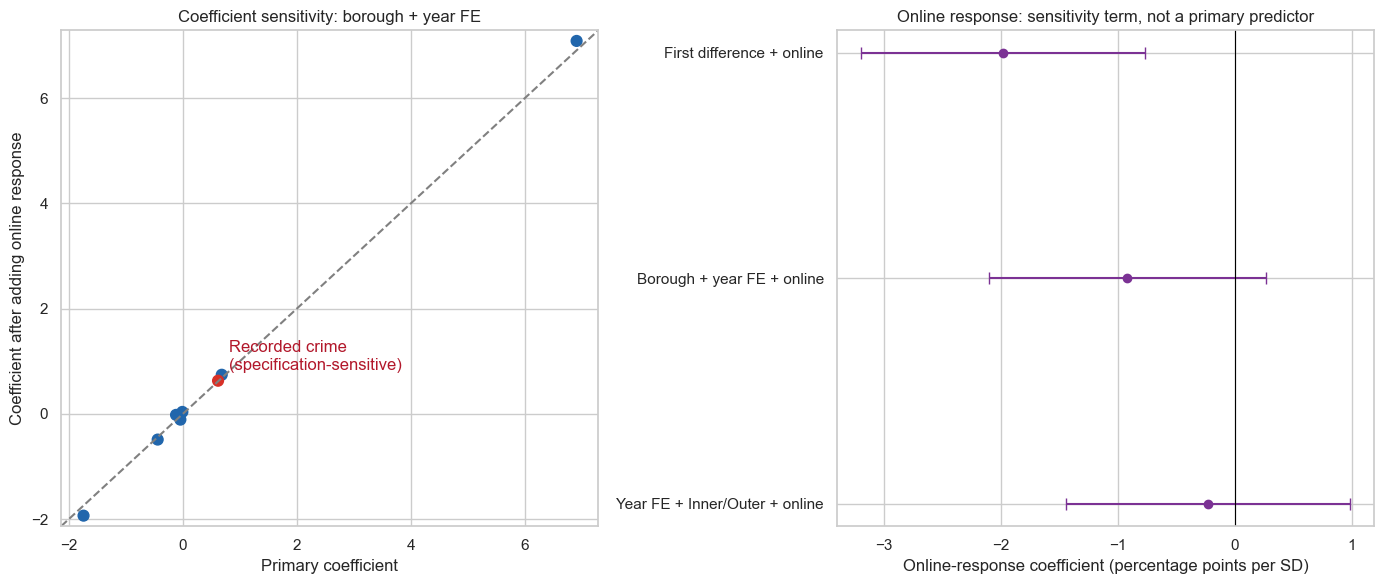

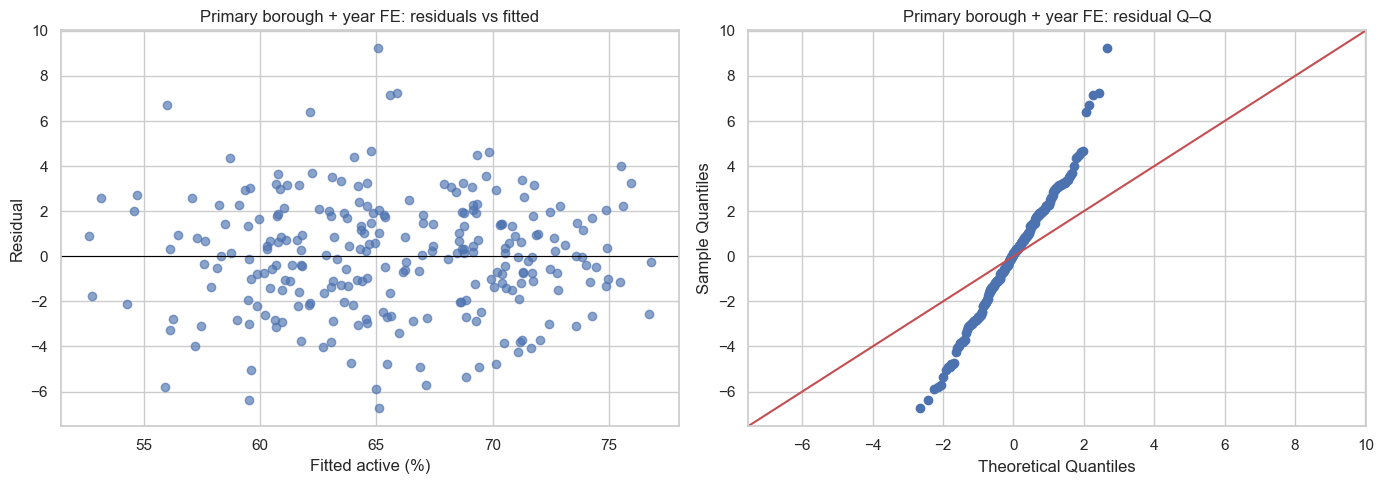

,model_role,feature,label,observed_cluster_t,wild_cluster_p_value,bootstrap_repeats
0,Primary borough + year FE,population_age_16_34_rate,Population aged 16–34,0.204,0.831,999
1,Primary borough + year FE,population_age_65_plus_rate,Population aged 65+,2.161,0.046,999
2,Primary borough + year FE,population_female_rate,Female population,-0.075,0.937,999
3,Primary borough + year FE,net_migration_per_1000,Net international migration,-0.023,0.987,999
4,Primary borough + year FE,earnings_relative_to_london,Earnings relative to London,-0.173,0.859,999
5,Primary borough + year FE,selected_recorded_crime_rate_per_1000,"Selected crime / 1,000\n(specification-sensiti...",1.426,0.443,999
6,Primary borough + year FE,older_adult_rate,Older adults in survey,-2.998,0.002,999
7,Primary borough + year FE,limiting_disability_rate,Disabled respondents,-1.736,0.094,999
8,Online-response sensitivity only,online_response_rate,Online response rate (sensitivity only),-1.526,0.117,999


In [15]:
def wild_cluster_pvalue(full_formula, data, weights, term, cluster, repeats=999):
    """Rademacher wild-cluster bootstrap-t p-value under H0: beta_term = 0."""
    restricted_formula = full_formula.replace(f' + {term}', '')
    full = smf.wls(full_formula, data=data, weights=weights).fit()
    restricted = smf.wls(restricted_formula, data=data, weights=weights).fit()
    observed = smf.wls(full_formula, data=data, weights=weights).fit(
        cov_type='cluster', cov_kwds={'groups': cluster}
    )
    observed_t = observed.params[term] / observed.bse[term]
    cluster_values = pd.Series(cluster).reset_index(drop=True)
    unique_clusters = cluster_values.unique()
    rng = np.random.default_rng(202603)
    bootstrap_t = []
    for _ in range(repeats):
        signs = pd.Series(rng.choice([-1, 1], size=len(unique_clusters)), index=unique_clusters)
        y_star = restricted.fittedvalues.to_numpy() + restricted.resid.to_numpy() * cluster_values.map(signs).to_numpy()
        boot_data = data.copy()
        boot_data['_wild_outcome'] = y_star
        boot_formula = full_formula.replace(full_formula.split('~')[0].strip(), '_wild_outcome', 1)
        boot = smf.wls(boot_formula, data=boot_data, weights=weights).fit(
            cov_type='cluster', cov_kwds={'groups': cluster}
        )
        bootstrap_t.append(boot.params[term] / boot.bse[term])
    p_value = (1 + np.sum(np.abs(bootstrap_t) >= abs(observed_t))) / (repeats + 1)
    return observed_t, p_value

BOOTSTRAP_REPEATS = 999
wild_rows = []
for feature in PRIMARY_RAW_FEATURES:
    term = f'z_{feature}'
    observed_t, p_value = wild_cluster_pvalue(
        fixed_effects_formula, analysis, analysis['weight'], term,
        analysis['geography_code'], repeats=BOOTSTRAP_REPEATS,
    )
    wild_rows.append({
        'model_role': 'Primary borough + year FE',
        'feature': feature,
        'label': FEATURE_LABELS[feature],
        'observed_cluster_t': observed_t,
        'wild_cluster_p_value': p_value,
        'bootstrap_repeats': BOOTSTRAP_REPEATS,
    })

online_t, online_p = wild_cluster_pvalue(
    fixed_effects_sensitivity_formula, analysis, analysis['weight'], ONLINE_STANDARD_FEATURE,
    analysis['geography_code'], repeats=BOOTSTRAP_REPEATS,
)
wild_rows.append({
    'model_role': 'Online-response sensitivity only',
    'feature': SENSITIVITY_FEATURE,
    'label': FEATURE_LABELS[SENSITIVITY_FEATURE],
    'observed_cluster_t': online_t,
    'wild_cluster_p_value': online_p,
    'bootstrap_repeats': BOOTSTRAP_REPEATS,
})
wild_cluster_results = pd.DataFrame(wild_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, specification in zip(axes, ['Borough + year FE', 'First difference']):
    frame = context_coefficients.loc[context_coefficients['specification'].eq(specification)].sort_values('coefficient')
    y = np.arange(len(frame))
    colours = ['#d73027' if f == 'selected_recorded_crime_rate_per_1000' else '#2166ac' for f in frame['feature']]
    ax.errorbar(
        frame['coefficient'], y,
        xerr=[frame['coefficient'] - frame['ci_low'], frame['ci_high'] - frame['coefficient']],
        fmt='none', ecolor='#777777', capsize=3, alpha=0.85,
    )
    ax.scatter(frame['coefficient'], y, c=colours, zorder=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y, frame['label'])
    ax.set_title(specification)
    ax.set_xlabel('Percentage-point change in activity per 1 SD change')
fig.suptitle('Primary models: adjusted contextual associations (95% cluster-robust CI)', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'context_model_coefficients.png', dpi=180, bbox_inches='tight')
plt.show()

main_fe = context_coefficients.loc[context_coefficients['specification'].eq('Borough + year FE')]
sens_fe = online_sensitivity_coefficients.loc[
    online_sensitivity_coefficients['specification'].eq('Borough + year FE + online')
]
coef_compare = main_fe[['feature', 'coefficient']].merge(
    sens_fe[['feature', 'coefficient']], on='feature', suffixes=('_primary', '_online_adjusted')
)
online_only = online_sensitivity_coefficients.loc[
    online_sensitivity_coefficients['feature'].eq(SENSITIVITY_FEATURE)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colours = np.where(coef_compare['feature'].eq('selected_recorded_crime_rate_per_1000'), '#d73027', '#2166ac')
axes[0].scatter(coef_compare['coefficient_primary'], coef_compare['coefficient_online_adjusted'], c=colours, s=60)
limits = [coef_compare[['coefficient_primary', 'coefficient_online_adjusted']].min().min() - 0.2,
          coef_compare[['coefficient_primary', 'coefficient_online_adjusted']].max().max() + 0.2]
axes[0].plot(limits, limits, linestyle='--', color='grey')
axes[0].set_xlim(limits); axes[0].set_ylim(limits)
axes[0].set_xlabel('Primary coefficient')
axes[0].set_ylabel('Coefficient after adding online response')
axes[0].set_title('Coefficient sensitivity: borough + year FE')
crime_point = coef_compare.loc[coef_compare['feature'].eq('selected_recorded_crime_rate_per_1000')].iloc[0]
axes[0].annotate('Recorded crime\n(specification-sensitive)',
                 (crime_point['coefficient_primary'], crime_point['coefficient_online_adjusted']),
                 xytext=(8, 8), textcoords='offset points', color='#b2182b')

y = np.arange(len(online_only))
axes[1].errorbar(
    online_only['coefficient'], y,
    xerr=[online_only['coefficient'] - online_only['ci_low'], online_only['ci_high'] - online_only['coefficient']],
    fmt='o', color='#7b3294', capsize=4,
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(y, online_only['specification'])
axes[1].set_xlabel('Online-response coefficient (percentage points per SD)')
axes[1].set_title('Online response: sensitivity term, not a primary predictor')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'online_response_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fixed_effects_model.fittedvalues, fixed_effects_model.resid, alpha=0.65)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Fitted active (%)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Primary borough + year FE: residuals vs fitted')
sm.qqplot(np.asarray(fixed_effects_model.resid), line='45', ax=axes[1])
axes[1].set_title('Primary borough + year FE: residual Q–Q')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

display(wild_cluster_results.round(3))

### Findings

`online_response_rate` is no longer a primary predictor. It appears only in three explicitly labelled sensitivity models and is excluded from the primary attribution. Its association differs materially by estimator: it is small in the year-effects plus Inner/Outer model (**-0.23 pp per SD, p = 0.708**), larger but still uncertain with borough and year effects (**-0.92, conventional p = 0.127; wild-cluster p = 0.117**), and larger in first differences (**-1.98, p = 0.001**). That disagreement is the reason to treat it as a survey-mode sensitivity check rather than substantive evidence.

The cross-sectional model explicitly controls for **Inner/Outer London**. The borough fixed-effects model does not repeat that control because the time-invariant classification is exactly absorbed by borough effects; first differencing removes it for the same reason. The primary maximum two-way-demeaned VIF is **2.02** (2.023 unrounded), and the online sensitivity maximum is also **2.02** (2.024 unrounded), replacing the outdated 1.66 figure.

With 999 Rademacher wild-cluster repetitions for every primary feature, the strongest fixed-effects result is the older-adult survey share (**p = 0.002**); age 65+ is **p = 0.046**, while limiting disability is **p = 0.094**. Recorded crime is explicitly labelled **specification-sensitive / not robust**: its sign changes from -0.56 in the cross-sectional model to +0.62 with borough fixed effects, and its fixed-effects wild-bootstrap p-value is **0.443**. All estimates remain descriptive rather than causal.

## 9. Descriptive model decomposition of change

The fixed-effects fitted difference is separated into contextual covariate contributions, the
common Year 8 effect and a borough residual. This closes the previous gap between the attribution
bars and observed change. The decomposition describes this fitted model; it is not causal and does
not identify borough policy effects.


,component,mean_contribution_pp,median_absolute_contribution_pp
0,Population age/sex,1.342768,1.606712
1,Income and migration,-0.000855,0.048213
2,Survey composition,-0.984367,0.814449
3,Recorded crime (specification-sensitive / not ...,0.237651,0.130089
4,common_year_effect,1.101374,1.101374
5,residual,0.058643,2.870378


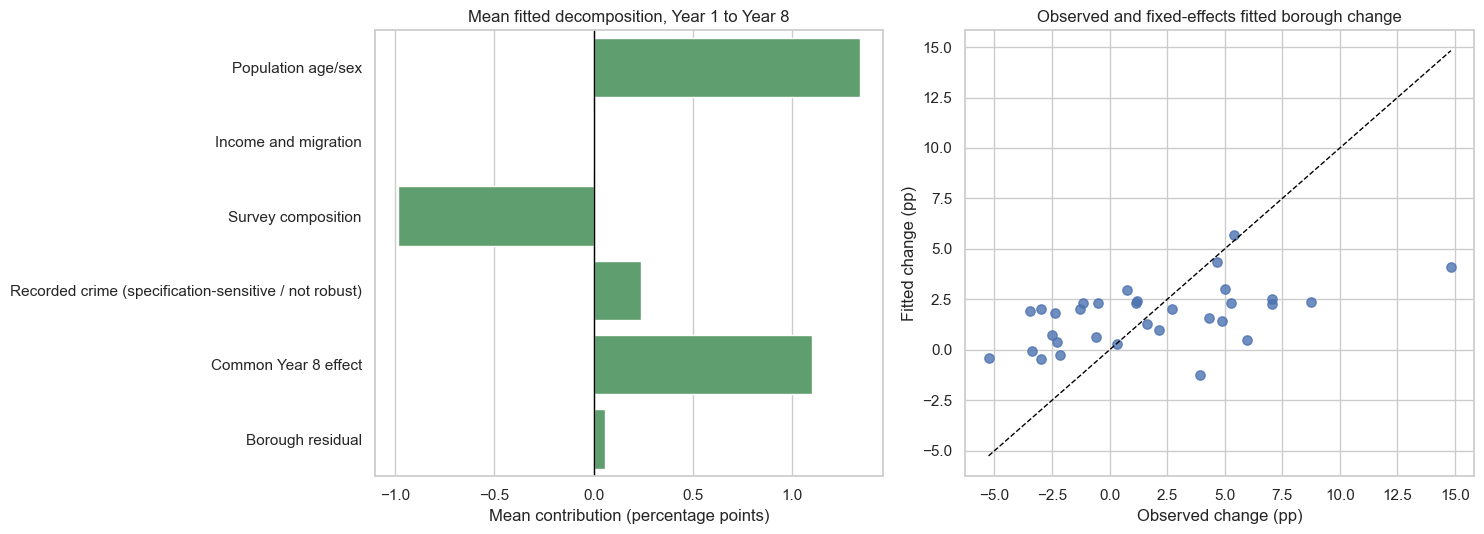

In [16]:
endpoint_change = analysis.loc[analysis['year'].isin([1, 8])].pivot(
    index='geography_code', columns='year', values=PRIMARY_STANDARD_FEATURES
)
observed_change = analysis.loc[analysis['year'].isin([1, 8])].pivot(
    index='geography_code', columns='year', values='active_pct'
)
attribution_rows = []
for borough in endpoint_change.index:
    row = {'geography_code': borough}
    for raw, standard in zip(PRIMARY_RAW_FEATURES, PRIMARY_STANDARD_FEATURES):
        delta = endpoint_change.loc[borough, (standard, 8)] - endpoint_change.loc[borough, (standard, 1)]
        row[raw] = delta * fixed_effects_model.params[standard]
    row['common_year_effect'] = fixed_effects_model.params.get('C(year)[T.8]', 0)
    row['observed_change'] = observed_change.loc[borough, 8] - observed_change.loc[borough, 1]
    attribution_rows.append(row)
trend_attribution_detail = pd.DataFrame(attribution_rows)

ATTRIBUTION_GROUPS = {
    'Population age/sex': [
        'population_age_16_34_rate', 'population_age_65_plus_rate', 'population_female_rate',
    ],
    'Income and migration': ['earnings_relative_to_london', 'net_migration_per_1000'],
    'Survey composition': ['older_adult_rate', 'limiting_disability_rate'],
    'Recorded crime (specification-sensitive / not robust)': ['selected_recorded_crime_rate_per_1000'],
}
for group_name, features in ATTRIBUTION_GROUPS.items():
    trend_attribution_detail[group_name] = trend_attribution_detail[features].sum(axis=1)
trend_attribution_detail['context_total'] = trend_attribution_detail[list(ATTRIBUTION_GROUPS)].sum(axis=1)
trend_attribution_detail['fitted_change'] = (
    trend_attribution_detail['context_total'] + trend_attribution_detail['common_year_effect']
)
trend_attribution_detail['residual'] = (
    trend_attribution_detail['observed_change'] - trend_attribution_detail['fitted_change']
)

decomposition_components = [*ATTRIBUTION_GROUPS, 'common_year_effect', 'residual']
trend_attribution = pd.DataFrame([
    {'component': component, 'mean_contribution_pp': trend_attribution_detail[component].mean(),
     'median_absolute_contribution_pp': trend_attribution_detail[component].abs().median()}
    for component in decomposition_components
])
display(trend_attribution)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
attribution_labels = {
    'common_year_effect': 'Common Year 8 effect',
    'residual': 'Borough residual',
}
trend_attribution_plot = trend_attribution.assign(
    component_label=trend_attribution['component'].replace(attribution_labels)
)
sns.barplot(data=trend_attribution_plot, x='mean_contribution_pp', y='component_label',
            ax=axes[0], color='#55a868')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set(title='Mean fitted decomposition, Year 1 to Year 8',
            xlabel='Mean contribution (percentage points)', ylabel='')
sns.regplot(data=trend_attribution_detail, x='observed_change', y='fitted_change', fit_reg=False,
            scatter_kws={'s': 45, 'alpha': .8}, ax=axes[1])
limits = np.array([
    trend_attribution_detail[['observed_change', 'fitted_change']].min().min(),
    trend_attribution_detail[['observed_change', 'fitted_change']].max().max(),
])
axes[1].plot(limits, limits, color='black', linestyle='--', linewidth=1)
axes[1].set(title='Observed and fixed-effects fitted borough change',
            xlabel='Observed change (pp)', ylabel='Fitted change (pp)')
fig.tight_layout()
save_figure(fig, 'trend_context_attribution.png')
plt.show()


### Findings

After removing online response from the primary specification, the common Year 8 component averages **+1.10 percentage points** and the median absolute borough residual is **2.87 points**. Population age/sex contributes +1.34 points on average, survey composition -0.98, income and migration approximately zero, and recorded crime +0.24; the crime component is retained only as a **specification-sensitive / not robust** descriptive item. The sizeable residual shows that this coefficient-based allocation does not explain the full observed borough change and must be read with the coefficient, VIF, sensitivity and residual diagnostics.

## 10. Borough clustering with de-duplicated features and sensitivity checks

Clusters use Years 1–6 only. Exact compositional duplicates, component-plus-total crime measures,
highly correlated activity averages and survey mode are excluded. The profile distinguishes active
level, linear trend and volatility, then adds one measure from each contextual domain. K-means and
Ward solutions with 2–8 groups are compared using all candidates; minimum cluster size is a visible
eligibility rule rather than a hidden plotting filter. PCA loadings, year-bootstrap stability,
Years 7–8 temporal validation and leave-one-feature-out sensitivity are reported.


In [17]:
cluster_panel = borough_annual.loc[borough_annual['year'].between(1, 6)].copy()


def build_cluster_profile(frame):
    means = frame.groupby(['geography_code', 'geography_name', 'inner_outer'], as_index=False).agg(
        active_level=('active_rate', 'mean'),
        limiting_disability=('limiting_disability_rate', 'mean'),
        population_age_65_plus=('population_age_65_plus_rate', 'mean'),
        relative_earnings=('earnings_relative_to_london', 'mean'),
        net_migration=('net_migration_per_1000', 'mean'),
        selected_crime=('selected_recorded_crime_rate_per_1000', 'mean'),
    )
    dynamics = []
    for geography_code, group in frame.groupby('geography_code'):
        x = group['year'].to_numpy(dtype=float)
        y = group['active_rate'].to_numpy(dtype=float) * 100
        slope = np.polyfit(x, y, 1)[0] if np.unique(x).size > 1 else 0.0
        dynamics.append({
            'geography_code': geography_code,
            'active_trend_pp_per_year': slope,
            'active_volatility_pp': np.std(y, ddof=0),
        })
    return means.merge(pd.DataFrame(dynamics), on='geography_code', validate='one_to_one')


profile = build_cluster_profile(cluster_panel)
cluster_features = [
    'active_level', 'active_trend_pp_per_year', 'active_volatility_pp',
    'limiting_disability', 'population_age_65_plus', 'relative_earnings',
    'net_migration', 'selected_crime',
]
cluster_feature_labels = {
    'active_level': 'Active level',
    'active_trend_pp_per_year': 'Active trend',
    'active_volatility_pp': 'Active volatility',
    'limiting_disability': 'Limiting disability',
    'population_age_65_plus': 'Population age 65+',
    'relative_earnings': 'Relative earnings',
    'net_migration': 'Net migration',
    'selected_crime': 'Selected crime (context; specification-sensitive)',
}
feature_correlations = profile[cluster_features].corr()

scaler = StandardScaler()
scaled_profile = scaler.fit_transform(profile[cluster_features])
pca = PCA(n_components=.90, random_state=RANDOM_STATE)
profile_scores = pca.fit_transform(scaled_profile)


def fit_labels(method, k, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(n_clusters=k, n_init=30, random_state=seed).fit_predict(values)
    return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(values)


bootstrap_geographies = profile['geography_code'].tolist()
bootstrap_years = np.arange(1, 7)
active_by_year = cluster_panel.pivot(
    index='geography_code', columns='year', values='active_rate'
).reindex(index=bootstrap_geographies, columns=bootstrap_years).to_numpy()
context_profile_features = [
    'limiting_disability_rate', 'population_age_65_plus_rate',
    'earnings_relative_to_london', 'net_migration_per_1000',
    'selected_recorded_crime_rate_per_1000',
]
context_by_year = np.stack([
    cluster_panel.pivot(index='geography_code', columns='year', values=feature)
    .reindex(index=bootstrap_geographies, columns=bootstrap_years).to_numpy()
    for feature in context_profile_features
], axis=2)


def resampled_cluster_matrix(sampled_years):
    positions = np.asarray(sampled_years) - 1
    active = active_by_year[:, positions] * 100
    x = np.asarray(sampled_years, dtype=float)
    centred_x = x - x.mean()
    denominator = np.square(centred_x).sum()
    slope = ((active - active.mean(axis=1, keepdims=True)) * centred_x).sum(axis=1)
    slope = slope / denominator if denominator > 0 else np.zeros(len(active))
    context = context_by_year[:, positions, :].mean(axis=1)
    return np.column_stack([
        active.mean(axis=1) / 100,
        slope,
        active.std(axis=1, ddof=0),
        context,
    ])


CLUSTER_BOOTSTRAP_REPEATS = 500

# Use identical resampled year blocks for every candidate. Besides being faster,
# common resamples make the stability comparison less sensitive to Monte Carlo noise.
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
bootstrap_profile_scores = []
for repeat in range(CLUSTER_BOOTSTRAP_REPEATS):
    sampled = bootstrap_rng.choice(bootstrap_years, size=len(bootstrap_years), replace=True)
    boot_scaled = StandardScaler().fit_transform(resampled_cluster_matrix(sampled))
    bootstrap_profile_scores.append(
        PCA(n_components=.90, random_state=RANDOM_STATE + repeat).fit_transform(boot_scaled)
    )


def bootstrap_stability(method, k, base_labels):
    scores = []
    for repeat, boot_scores in enumerate(bootstrap_profile_scores):
        if method == 'K-means':
            labels = KMeans(
                n_clusters=k, n_init=10, random_state=RANDOM_STATE + repeat
            ).fit_predict(boot_scores)
        else:
            labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(boot_scores)
        scores.append(adjusted_rand_score(base_labels, labels))
    return float(np.median(scores)), float(np.quantile(scores, .10))


candidate_rows = []
for method in ['K-means', 'Ward']:
    for k in range(2, 9):
        labels = fit_labels(method, k, profile_scores)
        counts = pd.Series(labels).value_counts()
        stability_median, stability_p10 = bootstrap_stability(method, k, labels)
        candidate_rows.append({
            'method': method, 'clusters': k,
            'stability_repeats': CLUSTER_BOOTSTRAP_REPEATS,
            'silhouette': silhouette_score(profile_scores, labels),
            'calinski_harabasz': calinski_harabasz_score(profile_scores, labels),
            'davies_bouldin': davies_bouldin_score(profile_scores, labels),
            'stability_median_ari': stability_median,
            'stability_p10_ari': stability_p10,
            'smallest_cluster': int(counts.min()),
        })

cluster_candidates = pd.DataFrame(candidate_rows)
cluster_candidates['eligible'] = cluster_candidates['smallest_cluster'].ge(4)
eligible_index = cluster_candidates.index[cluster_candidates['eligible']]
for column, direction in [
    ('silhouette', 1), ('calinski_harabasz', 1), ('davies_bouldin', -1),
    ('stability_median_ari', 1), ('stability_p10_ari', 1),
]:
    good = direction * cluster_candidates.loc[eligible_index, column]
    cluster_candidates.loc[eligible_index, f'rank_{column}'] = good.rank(pct=True)
rank_columns = [column for column in cluster_candidates if column.startswith('rank_')]
cluster_candidates['selection_score'] = cluster_candidates[rank_columns].mean(axis=1)
winner = cluster_candidates.loc[cluster_candidates['eligible']].sort_values(
    ['selection_score', 'stability_median_ari', 'silhouette'], ascending=False
).iloc[0]
selected_method, selected_k = winner['method'], int(winner['clusters'])
profile['cluster_id'] = fit_labels(selected_method, selected_k, profile_scores) + 1

cluster_means = profile.groupby('cluster_id')[cluster_features].mean()
cluster_order = cluster_means['active_level'].sort_values().index
cluster_rank = {cluster_id: rank for rank, cluster_id in enumerate(cluster_order, start=1)}
profile['cluster_id'] = profile['cluster_id'].map(cluster_rank)
cluster_names = {
    rank: f'C{rank}: {"higher" if rank == selected_k else "lower" if rank == 1 else "mid"} activity'
    for rank in range(1, selected_k + 1)
}
profile['cluster_label'] = profile['cluster_id'].map(cluster_names)
inner_outer_codes = profile['inner_outer'].astype('category').cat.codes
inner_outer_ari = adjusted_rand_score(inner_outer_codes, profile['cluster_id'])

pca_coordinates = profile[
    ['geography_code', 'geography_name', 'inner_outer', 'cluster_id', 'cluster_label']
].copy()
pca_coordinates['PC1'] = profile_scores[:, 0]
pca_coordinates['PC2'] = profile_scores[:, 1]
pca_explained = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(pca.n_components_)],
    'explained_variance': pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_),
})
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=[cluster_feature_labels[x] for x in cluster_features],
    columns=pca_explained['component'],
)

late_profile = build_cluster_profile(borough_annual.loc[borough_annual['year'].between(7, 8)]).set_index(
    'geography_code'
).reindex(profile['geography_code']).reset_index()
late_scaled = StandardScaler().fit_transform(late_profile[cluster_features])
late_scores = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(late_scaled)
late_labels = fit_labels(selected_method, selected_k, late_scores)
temporal_validation_ari = adjusted_rand_score(profile['cluster_id'] - 1, late_labels)

sensitivity_rows = []
for omitted in cluster_features:
    retained = [feature for feature in cluster_features if feature != omitted]
    values = StandardScaler().fit_transform(profile[retained])
    scores = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(values)
    labels = fit_labels(selected_method, selected_k, scores)
    sensitivity_rows.append({
        'omitted_feature': omitted,
        'assignment_ari': adjusted_rand_score(profile['cluster_id'] - 1, labels),
    })
cluster_sensitivity = pd.DataFrame(sensitivity_rows)

display(cluster_candidates.sort_values(['eligible', 'selection_score'], ascending=False))
display(pca_explained)
display(pca_loadings)
display(cluster_sensitivity.sort_values('assignment_ari'))
print(f'Selected: {selected_method}, k={selected_k}; Inner/Outer ARI={inner_outer_ari:.3f}; '
      f'Years 7–8 validation ARI={temporal_validation_ari:.3f}')


borough_cluster_membership = profile[[
    'geography_code', 'geography_name', 'inner_outer', 'cluster_id', 'cluster_label'
]].sort_values(['cluster_id', 'geography_name']).reset_index(drop=True)
borough_cluster_membership.insert(0, 'map_id', np.arange(1, len(borough_cluster_membership) + 1))
display(borough_cluster_membership)

,method,clusters,stability_repeats,silhouette,calinski_harabasz,davies_bouldin,stability_median_ari,stability_p10_ari,smallest_cluster,eligible,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,rank_stability_median_ari,rank_stability_p10_ari,selection_score
0,K-means,2,500,0.212148,9.638650,1.667127,0.649513,0.548438,15,True,0.9,0.9,0.3,1.0,1.0,0.82
7,Ward,2,500,0.212148,9.638650,1.667127,0.649034,0.373889,15,True,0.9,0.9,0.3,0.8,0.8,0.74
8,Ward,3,500,0.210592,8.480397,1.439826,0.458309,0.281050,4,True,0.6,0.4,0.6,0.6,0.6,0.56
1,K-means,3,500,0.209082,8.547066,1.416823,0.331926,0.242482,4,True,0.4,0.6,0.8,0.2,0.2,0.44
2,K-means,4,500,0.186983,8.294771,1.387049,0.450211,0.277331,4,True,0.2,0.2,1.0,0.4,0.4,0.44
3,K-means,5,500,0.168277,7.814792,1.349503,0.416045,0.262604,3,False,NaN,NaN,NaN,NaN,NaN,NaN
4,K-means,6,500,0.187784,7.554947,1.233804,0.418991,0.243981,3,False,NaN,NaN,NaN,NaN,NaN,NaN
5,K-means,7,500,0.180376,7.764178,1.156089,0.425263,0.281290,1,False,NaN,NaN,NaN,NaN,NaN,NaN
6,K-means,8,500,0.216196,8.105819,0.949843,0.368347,0.206037,1,False,NaN,NaN,NaN,NaN,NaN,NaN
9,Ward,4,500,0.210194,8.338030,1.318762,0.453202,0.263477,3,False,NaN,NaN,NaN,NaN,NaN,NaN


,component,explained_variance,cumulative_variance
0,PC1,0.299204,0.299204
1,PC2,0.192736,0.491940
2,PC3,0.170603,0.662543
3,PC4,0.128064,0.790607
4,PC5,0.094987,0.885594
5,PC6,0.069591,0.955185


component,PC1,PC2,PC3,PC4,PC5,PC6
Active level,0.557069,0.066255,-0.240349,-0.202131,0.039844,-0.111494
Active trend,0.287761,-0.302085,-0.559797,0.162729,-0.218109,-0.447115
Active volatility,-0.207502,0.447483,-0.197910,-0.044093,-0.827222,0.139054
Limiting disability,-0.319965,0.348075,-0.358025,0.459427,0.262797,-0.386486
Population age 65+,-0.275780,0.038485,-0.617156,-0.151219,0.353869,0.542102
Relative earnings,0.546798,0.280231,-0.169782,-0.057623,0.037490,0.345802
Net migration,-0.013526,0.580812,0.075730,-0.540001,0.240732,-0.419124
Selected crime (context; specification-sensitive),0.293611,0.406947,0.214631,0.633921,0.113584,0.172718


,omitted_feature,assignment_ari
0,active_level,0.457374
5,relative_earnings,0.648874
2,active_volatility_pp,0.649513
3,limiting_disability,0.757872
6,net_migration,0.874886
1,active_trend_pp_per_year,1.000000
4,population_age_65_plus,1.000000
7,selected_crime,1.000000


Selected: K-means, k=2; Inner/Outer ARI=0.226; Years 7–8 validation ARI=0.295


,map_id,geography_code,geography_name,inner_outer,cluster_id,cluster_label
0,1,E09000002,Barking and Dagenham,Outer London,1,C1: lower activity
1,2,E09000003,Barnet,Outer London,1,C1: lower activity
2,3,E09000004,Bexley,Outer London,1,C1: lower activity
3,4,E09000005,Brent,Outer London,1,C1: lower activity
4,5,E09000008,Croydon,Outer London,1,C1: lower activity
5,6,E09000009,Ealing,Outer London,1,C1: lower activity
6,7,E09000010,Enfield,Outer London,1,C1: lower activity
7,8,E09000014,Haringey,Inner London,1,C1: lower activity
8,9,E09000015,Harrow,Outer London,1,C1: lower activity
9,10,E09000016,Havering,Outer London,1,C1: lower activity


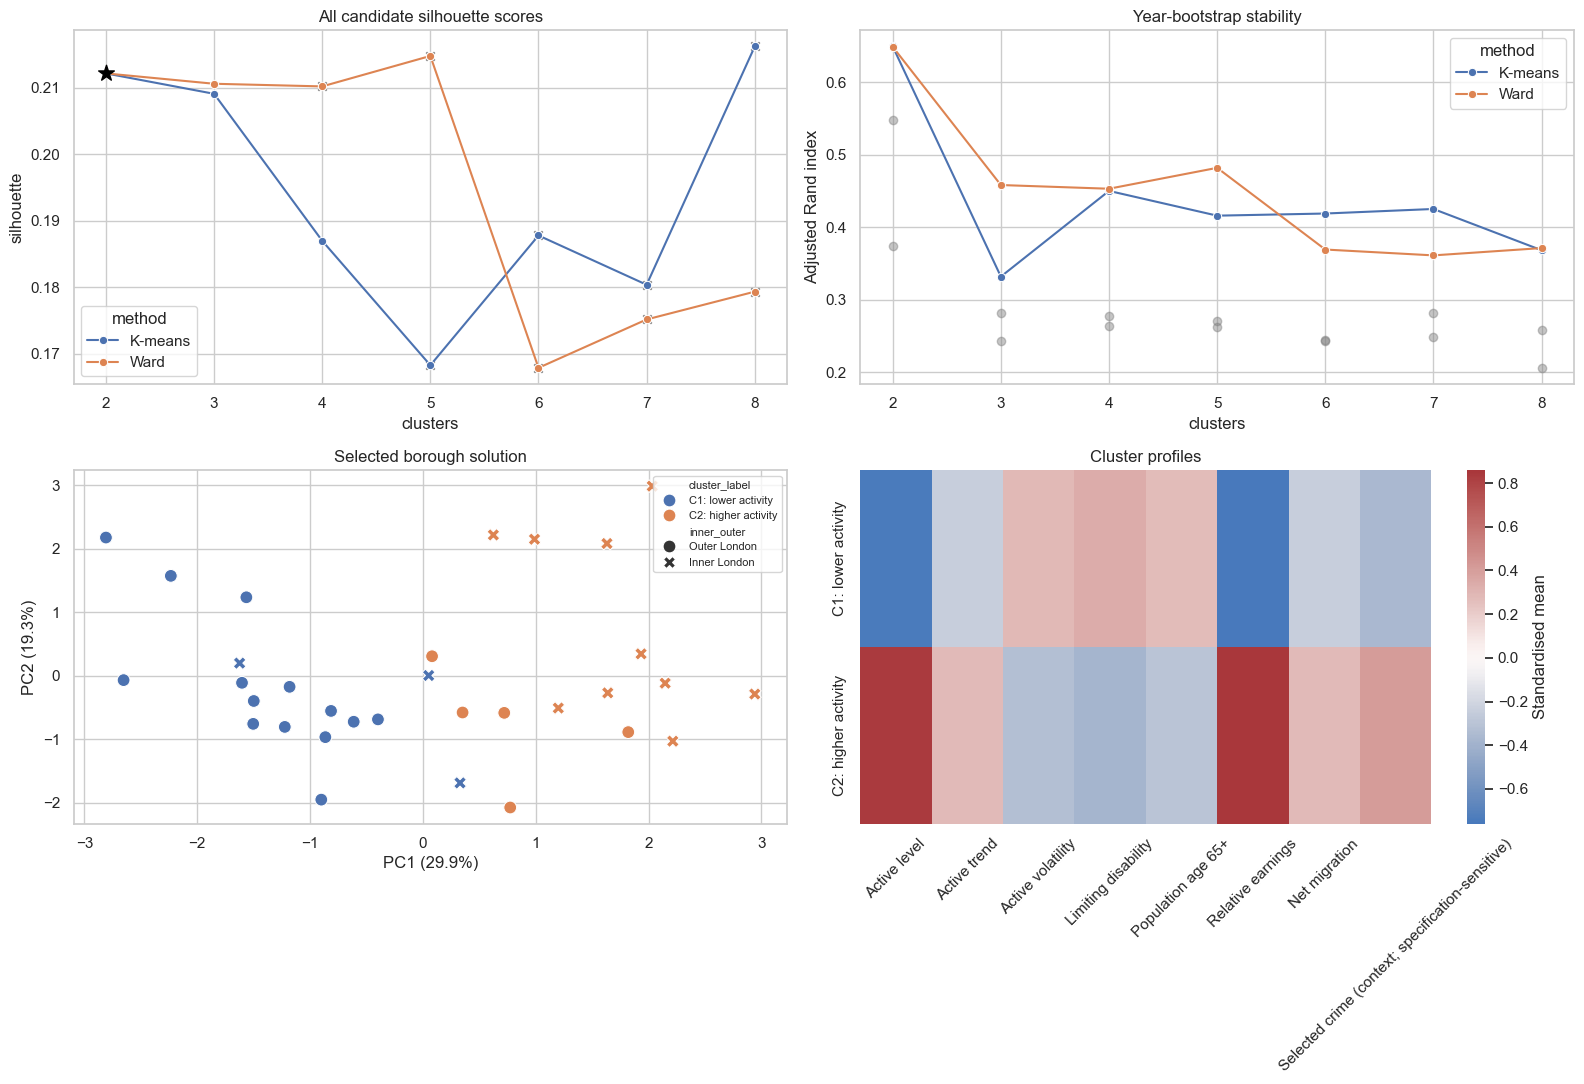

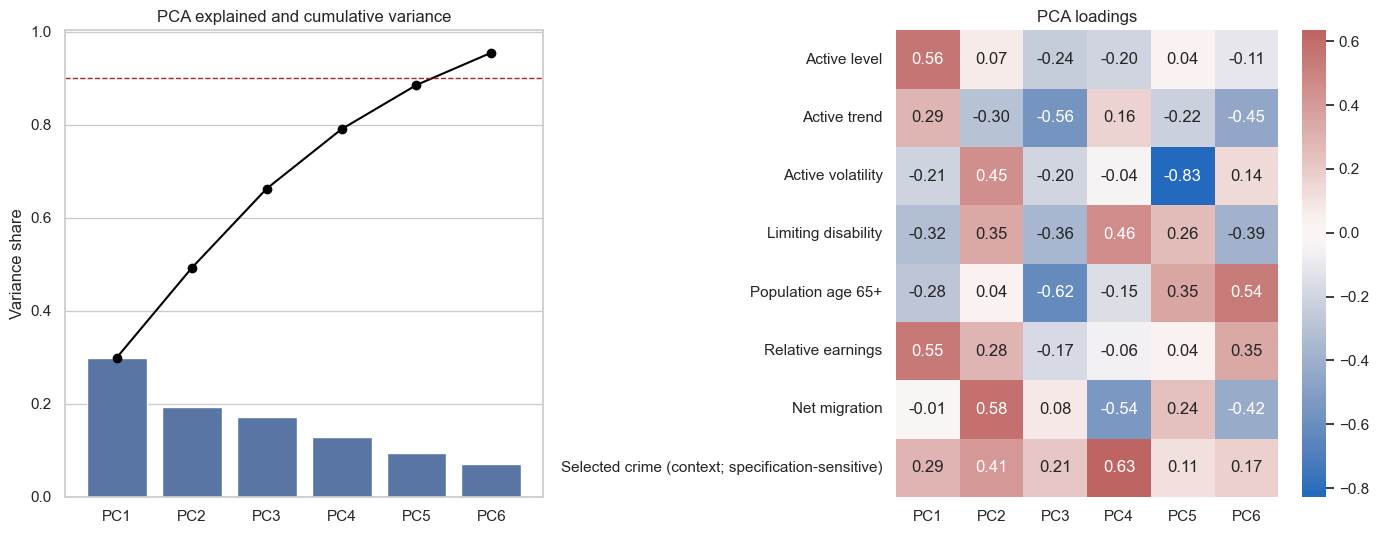

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.lineplot(data=cluster_candidates, x='clusters', y='silhouette', hue='method', marker='o', ax=axes[0, 0])
rejected = cluster_candidates.loc[~cluster_candidates['eligible']]
axes[0, 0].scatter(rejected['clusters'], rejected['silhouette'], marker='x', color='grey', label='Rejected: min n < 4')
axes[0, 0].scatter([selected_k], [winner['silhouette']], s=140, marker='*', color='black', zorder=5)
axes[0, 0].set_title('All candidate silhouette scores')

sns.lineplot(data=cluster_candidates, x='clusters', y='stability_median_ari', hue='method', marker='o',
             ax=axes[0, 1])
axes[0, 1].plot(cluster_candidates['clusters'], cluster_candidates['stability_p10_ari'],
                'o', color='grey', alpha=.45, label='10th-percentile ARI')
axes[0, 1].set(title='Year-bootstrap stability', ylabel='Adjusted Rand index')

sns.scatterplot(data=pca_coordinates, x='PC1', y='PC2', hue='cluster_label', style='inner_outer',
                s=85, ax=axes[1, 0])
axes[1, 0].set(
    title='Selected borough solution',
    xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
)
axes[1, 0].legend(fontsize=8, loc='best')

heat = profile.groupby('cluster_label')[cluster_features].mean()
heat = (heat - profile[cluster_features].mean()) / profile[cluster_features].std(ddof=0)
heat.columns = [cluster_feature_labels[x] for x in heat.columns]
sns.heatmap(heat, cmap='vlag', center=0, ax=axes[1, 1], cbar_kws={'label': 'Standardised mean'})
axes[1, 1].set_title('Cluster profiles')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
fig.tight_layout()
save_figure(fig, 'borough_cluster_selection_and_profiles.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(data=pca_explained, x='component', y='explained_variance', color='#4c72b0', ax=axes[0])
axes[0].plot(pca_explained['component'], pca_explained['cumulative_variance'], marker='o', color='black')
axes[0].axhline(.90, color='firebrick', linestyle='--', linewidth=1)
axes[0].set(title='PCA explained and cumulative variance', ylabel='Variance share', xlabel='')
sns.heatmap(pca_loadings, cmap='vlag', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set(title='PCA loadings', xlabel='', ylabel='')
fig.tight_layout()
save_figure(fig, 'borough_cluster_pca_explanation.png')
plt.show()


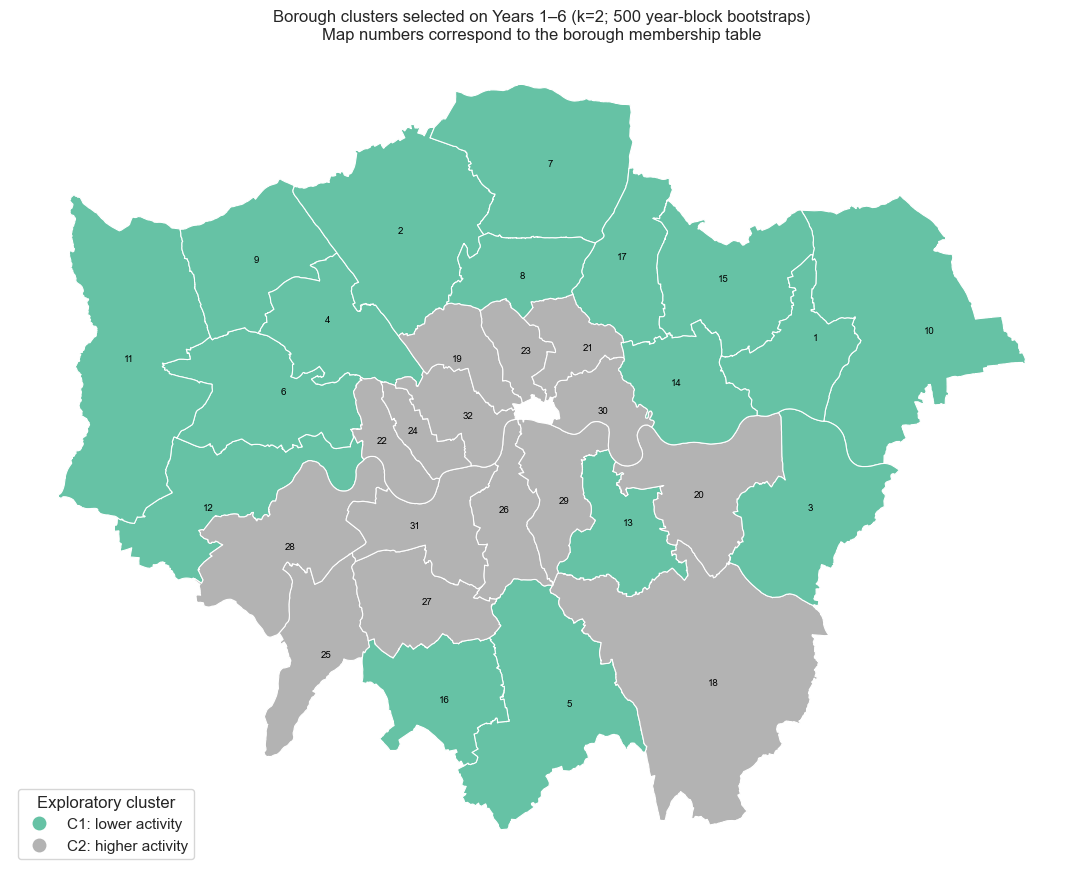

,map_id,geography_code,geography_name,inner_outer,cluster_id,cluster_label
0,1,E09000002,Barking and Dagenham,Outer London,1,C1: lower activity
1,2,E09000003,Barnet,Outer London,1,C1: lower activity
2,3,E09000004,Bexley,Outer London,1,C1: lower activity
3,4,E09000005,Brent,Outer London,1,C1: lower activity
4,5,E09000008,Croydon,Outer London,1,C1: lower activity
5,6,E09000009,Ealing,Outer London,1,C1: lower activity
6,7,E09000010,Enfield,Outer London,1,C1: lower activity
7,8,E09000014,Haringey,Inner London,1,C1: lower activity
8,9,E09000015,Harrow,Outer London,1,C1: lower activity
9,10,E09000016,Havering,Outer London,1,C1: lower activity


In [19]:
cluster_map_boundaries = borough_boundaries.loc[
    borough_boundaries['gss_code'].isin(borough_cluster_membership['geography_code'])
].copy()
assert len(cluster_map_boundaries) == 32
cluster_membership_map = cluster_map_boundaries.merge(
    borough_cluster_membership,
    left_on='gss_code', right_on='geography_code', how='left', validate='one_to_one'
)
assert cluster_membership_map['cluster_id'].notna().all(), 'Every borough boundary must receive one cluster.'

fig, ax = plt.subplots(figsize=(11, 11))
cluster_membership_map.plot(
    column='cluster_label', categorical=True, legend=True, cmap='Set2',
    edgecolor='white', linewidth=0.8, ax=ax,
    legend_kwds={'title': 'Exploratory cluster', 'loc': 'lower left'},
)
for _, row in cluster_membership_map.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, str(int(row['map_id'])), ha='center', va='center', fontsize=7, color='black')
ax.set_axis_off()
ax.set_title(
    f'Borough clusters selected on Years 1–6 (k={selected_k}; '
    f'{CLUSTER_BOOTSTRAP_REPEATS} year-block bootstraps)\n'
    'Map numbers correspond to the borough membership table'
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'borough_cluster_map.png', dpi=200, bbox_inches='tight')
plt.show()

display(borough_cluster_membership)

### Independent two-year clustering with 2-8 candidate groups

Four non-overlapping windows (Years 1-2, 3-4, 5-6 and 7-8) are clustered independently. Each window evaluates K-means and Ward solutions for `k=2` through `k=8`; two groups are no longer imposed from the Years 1-6 primary result.

Candidate selection uses silhouette, Calinski-Harabasz, Davies-Bouldin and leave-one-feature-out assignment stability. Solutions with fewer than four boroughs in any group remain visible but are ineligible for selection. Every K-means candidate uses 100 initialisations. Each window uses mean activity and contextual levels plus the two-year Active change; two-point volatility is excluded because it duplicates absolute endpoint change.

Because independently selected windows may have different `k`, cluster IDs are ordered by Active level within each window and converted to a 0-1 relative rank. ARI and pairwise co-clustering remain valid even when the number of groups differs.


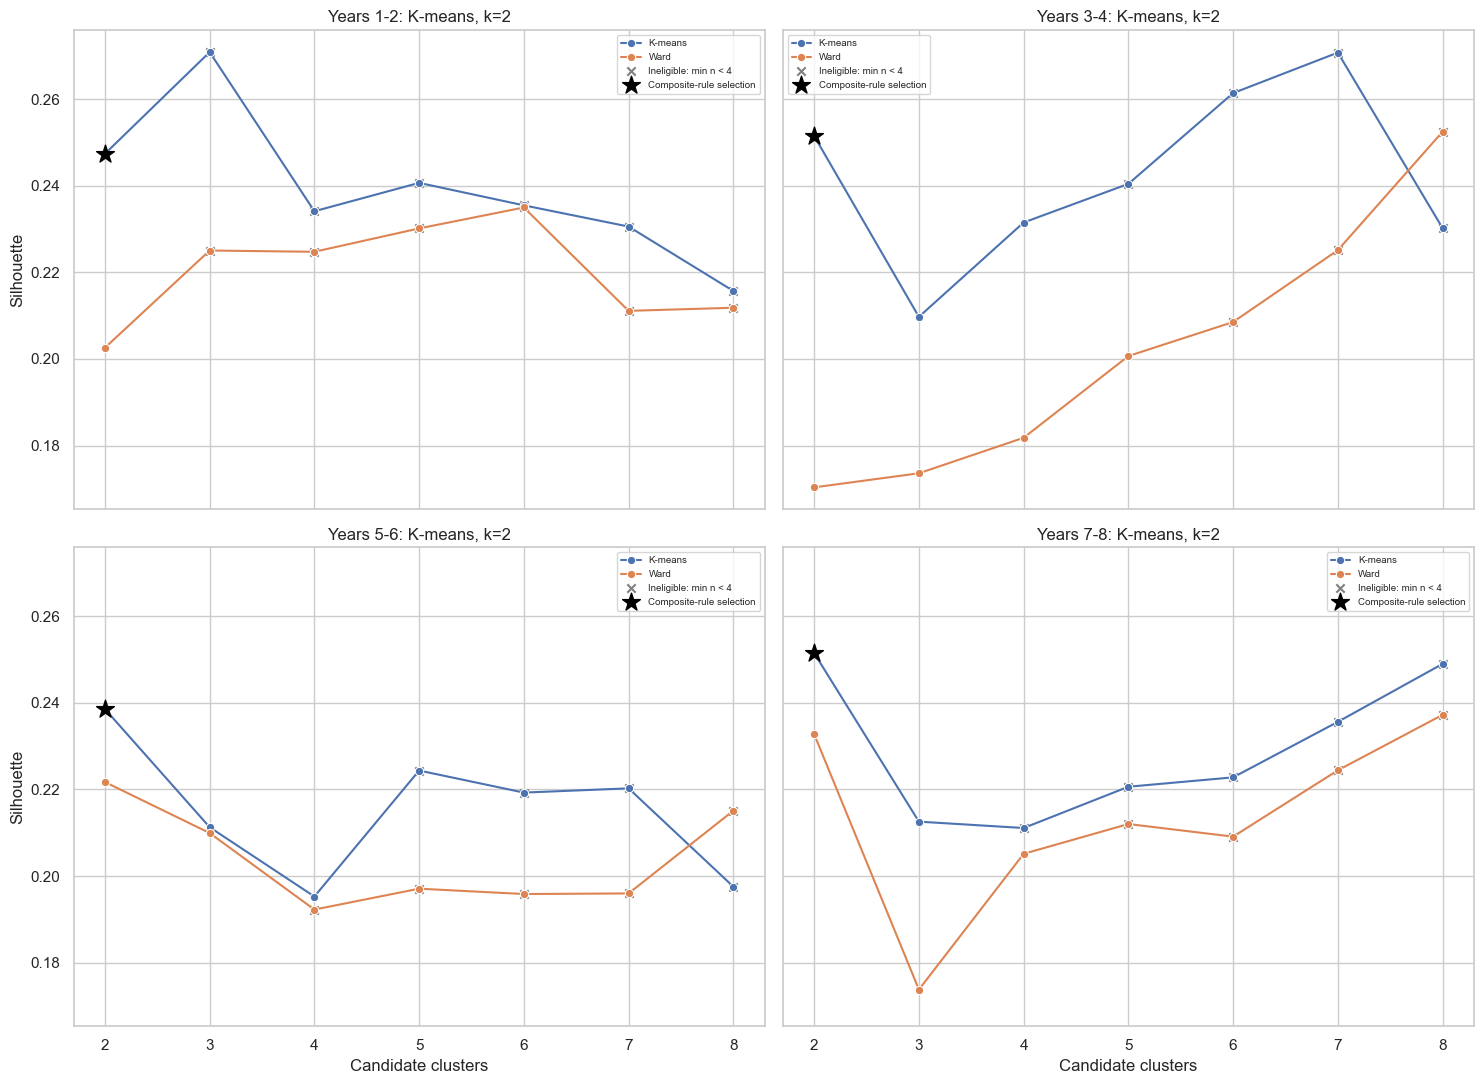

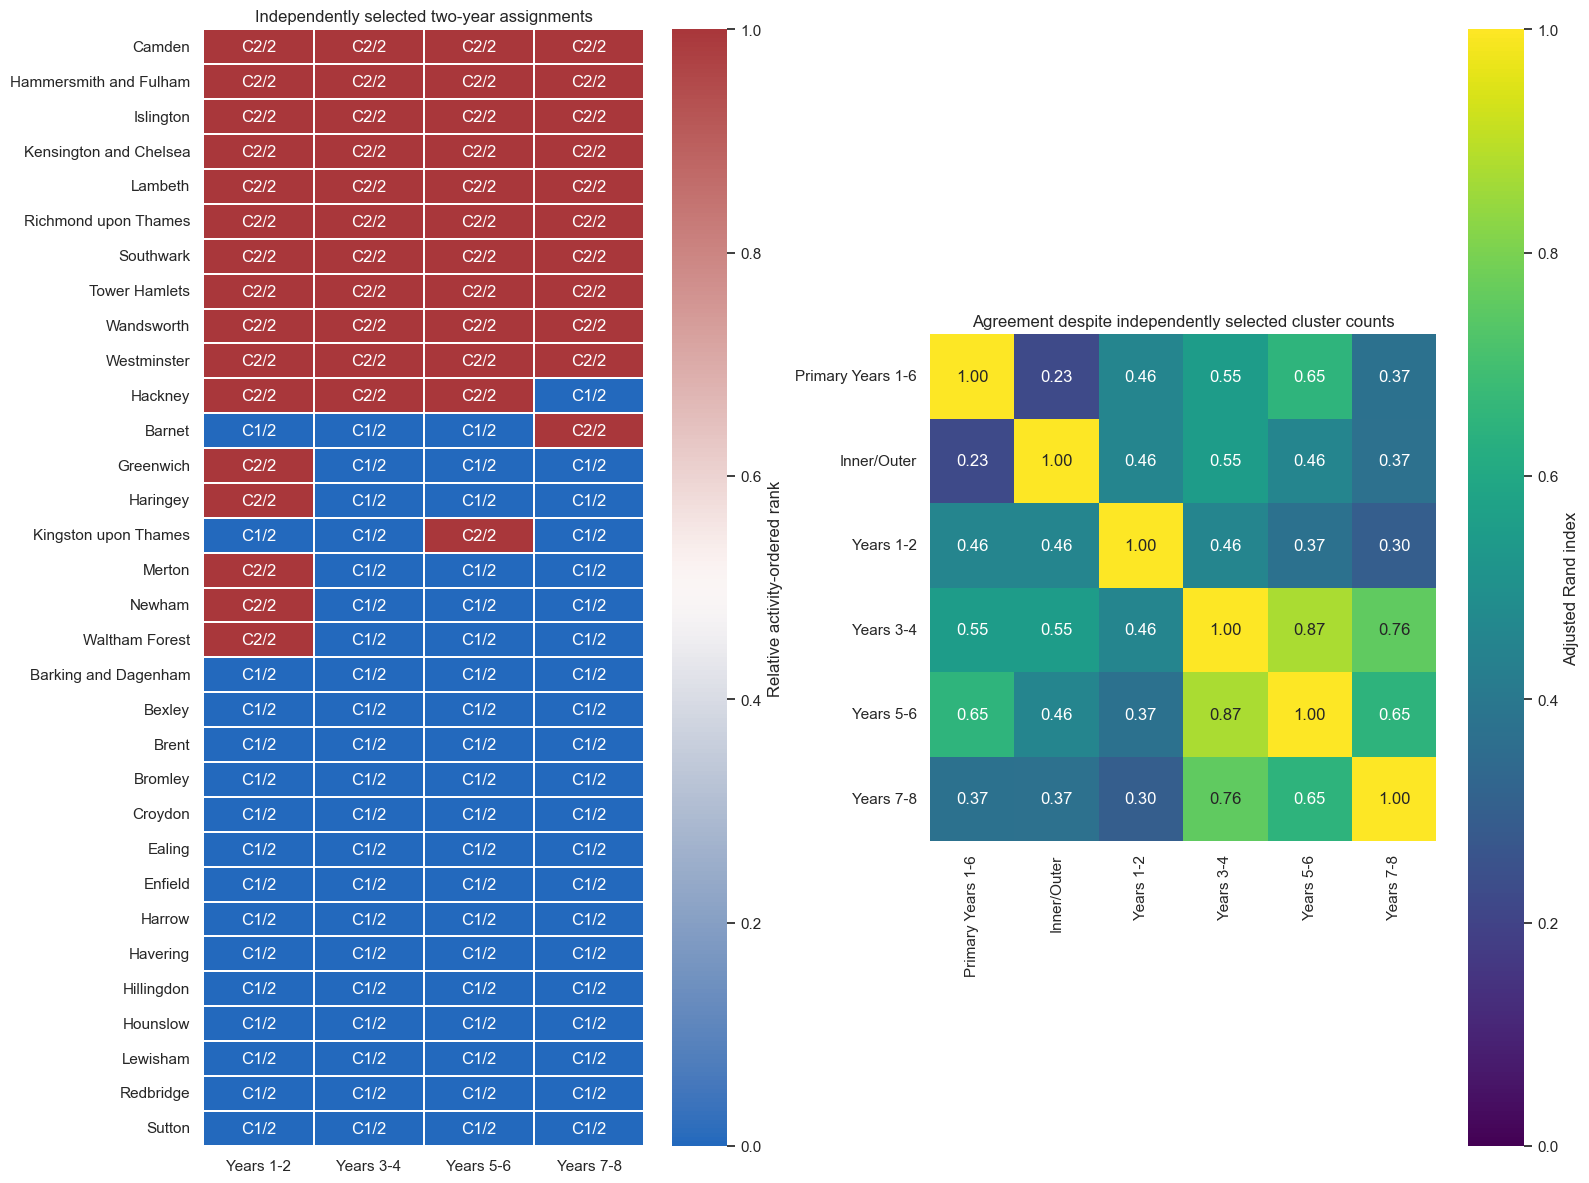

,window,window_start,window_end,candidate_id,method,clusters,kmeans_n_init,pca_components_retained,pca_variance_retained,silhouette,calinski_harabasz,davies_bouldin,feature_omission_median_ari,feature_omission_p10_ari,smallest_cluster,largest_cluster,eligible,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,rank_feature_omission_median_ari,rank_feature_omission_p10_ari,selection_score,selected
0,Years 1-2,1,2,Years 1-2_K-means_k2,K-means,2,100.0,5,0.950454,0.247352,11.711589,1.467619,0.757939,0.477963,16,16,True,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,True
7,Years 1-2,1,2,Years 1-2_Ward_k2,Ward,2,NaN,5,0.950454,0.202581,9.628571,1.613605,0.371039,0.266496,15,17,True,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,False
1,Years 1-2,1,2,Years 1-2_K-means_k3,K-means,3,100.0,5,0.950454,0.270828,11.070003,1.186253,0.493791,0.455496,2,16,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,Years 1-2,1,2,Years 1-2_K-means_k4,K-means,4,100.0,5,0.950454,0.234089,11.348326,1.121978,0.724533,0.382862,2,11,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,Years 1-2,1,2,Years 1-2_K-means_k5,K-means,5,100.0,5,0.950454,0.240642,11.211929,1.109553,0.681992,0.565734,2,9,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,Years 1-2,1,2,Years 1-2_K-means_k6,K-means,6,100.0,5,0.950454,0.235454,11.124662,1.026218,0.570153,0.550904,2,8,False,NaN,NaN,NaN,NaN,NaN,NaN,False
5,Years 1-2,1,2,Years 1-2_K-means_k7,K-means,7,100.0,5,0.950454,0.230554,10.395367,1.045441,0.532887,0.441320,2,9,False,NaN,NaN,NaN,NaN,NaN,NaN,False
6,Years 1-2,1,2,Years 1-2_K-means_k8,K-means,8,100.0,5,0.950454,0.215694,9.794608,0.903715,0.546696,0.375077,1,8,False,NaN,NaN,NaN,NaN,NaN,NaN,False
8,Years 1-2,1,2,Years 1-2_Ward_k3,Ward,3,NaN,5,0.950454,0.225027,9.552110,1.310975,0.411926,0.314190,2,15,False,NaN,NaN,NaN,NaN,NaN,NaN,False
9,Years 1-2,1,2,Years 1-2_Ward_k4,Ward,4,NaN,5,0.950454,0.224731,10.086072,1.191899,0.526856,0.475145,2,15,False,NaN,NaN,NaN,NaN,NaN,NaN,False


,scope,window_start,method,clusters,feature_count,dynamic_feature_design,silhouette,smallest_cluster,stability_measure,stability_median_ari,stability_p10_ari,ari_with_inner_outer,ari_with_primary_years_1_6,ari_with_previous_window
0,Primary Years 1-6,0,K-means,2,8,Six-year Active trend and volatility,0.212,15,500 year-block bootstraps,0.650,0.548,0.226,1.000,NaN
1,Years 1-2,1,K-means,2,7,Two-year Active change,0.247,16,Leave-one-feature-out ARI,0.758,0.478,0.456,0.455,NaN
2,Years 3-4,3,K-means,2,7,Two-year Active change,0.251,11,Leave-one-feature-out ARI,0.758,0.647,0.548,0.549,0.457
3,Years 5-6,5,K-means,2,7,Two-year Active change,0.239,12,Leave-one-feature-out ARI,0.757,0.608,0.456,0.650,0.875
4,Years 7-8,7,K-means,2,7,Two-year Active change,0.251,11,Leave-one-feature-out ARI,0.874,0.713,0.371,0.372,0.648


,geography_code,geography_name,inner_outer,top_cluster_windows,bottom_cluster_windows,mean_relative_cluster_rank,relative_cluster_rank_sd,large_rank_shifts,primary_cluster_id,assignment_pattern
0,E09000007,Camden,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
1,E09000013,Hammersmith and Fulham,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
2,E09000019,Islington,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
3,E09000020,Kensington and Chelsea,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
4,E09000022,Lambeth,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
5,E09000027,Richmond upon Thames,Outer London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
6,E09000028,Southwark,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
7,E09000030,Tower Hamlets,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
8,E09000032,Wandsworth,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2
9,E09000033,Westminster,Inner London,4,0,1.00,0.000000,0,2,C2/2 -> C2/2 -> C2/2 -> C2/2


In [20]:
TWO_YEAR_WINDOWS = [(1, 2), (3, 4), (5, 6), (7, 8)]
TWO_YEAR_K_VALUES = range(2, 9)
TWO_YEAR_METHODS = ['K-means', 'Ward']
TWO_YEAR_MIN_CLUSTER_SIZE = 4
TWO_YEAR_KMEANS_N_INIT = 100
two_year_features = [
    'active_level', 'active_change_pp', 'limiting_disability',
    'population_age_65_plus', 'relative_earnings', 'net_migration', 'selected_crime',
]


def build_two_year_profile(frame, start_year, end_year):
    window = frame.loc[frame['year'].between(start_year, end_year)].copy()
    assert window['year'].nunique() == 2
    means = window.groupby(
        ['geography_code', 'geography_name', 'inner_outer'], as_index=False
    ).agg(
        active_level=('active_rate', 'mean'),
        limiting_disability=('limiting_disability_rate', 'mean'),
        population_age_65_plus=('population_age_65_plus_rate', 'mean'),
        relative_earnings=('earnings_relative_to_london', 'mean'),
        net_migration=('net_migration_per_1000', 'mean'),
        selected_crime=('selected_recorded_crime_rate_per_1000', 'mean'),
    )
    endpoints = window.pivot(index='geography_code', columns='year', values='active_rate')
    change = ((endpoints[end_year] - endpoints[start_year]) * 100).rename('active_change_pp')
    result = means.merge(change, on='geography_code', validate='one_to_one')
    assert len(result) == 32 and result[two_year_features].notna().all().all()
    return result


def fit_two_year_labels(method, clusters, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(
            n_clusters=clusters, n_init=TWO_YEAR_KMEANS_N_INIT, random_state=seed
        ).fit_predict(values)
    return AgglomerativeClustering(n_clusters=clusters, linkage='ward').fit_predict(values)


def order_labels_by_activity(frame, raw_labels):
    order = (
        frame.assign(raw_cluster=raw_labels)
        .groupby('raw_cluster')['active_level'].mean().sort_values().index
    )
    mapping = {raw: rank for rank, raw in enumerate(order, start=1)}
    return pd.Series(raw_labels).map(mapping).to_numpy()


def activity_ordered_label(cluster_id, clusters):
    if cluster_id == 1:
        descriptor = 'lower activity'
    elif cluster_id == clusters:
        descriptor = 'higher activity'
    else:
        descriptor = 'intermediate activity'
    return f'C{cluster_id}/{clusters}: {descriptor}'


primary_by_code = profile.set_index('geography_code')['cluster_id']
two_year_candidate_rows, two_year_all_membership_parts = [], []
window_profiles, window_scores_lookup = {}, {}

for start_year, end_year in TWO_YEAR_WINDOWS:
    window_name = f'Years {start_year}-{end_year}'
    window_profile = build_two_year_profile(borough_annual, start_year, end_year)
    scaled = StandardScaler().fit_transform(window_profile[two_year_features])
    window_pca = PCA(n_components=.90, random_state=RANDOM_STATE).fit(scaled)
    scores = window_pca.transform(scaled)
    window_profiles[window_name] = window_profile
    window_scores_lookup[window_name] = scores

    for method in TWO_YEAR_METHODS:
        for clusters in TWO_YEAR_K_VALUES:
            raw_labels = fit_two_year_labels(method, clusters, scores)
            ordered_labels = order_labels_by_activity(window_profile, raw_labels)
            counts = pd.Series(ordered_labels).value_counts()
            omission_ari = []
            for omitted in two_year_features:
                retained = [feature for feature in two_year_features if feature != omitted]
                retained_scaled = StandardScaler().fit_transform(window_profile[retained])
                retained_scores = PCA(
                    n_components=.90, random_state=RANDOM_STATE
                ).fit_transform(retained_scaled)
                omitted_labels = fit_two_year_labels(method, clusters, retained_scores)
                omission_ari.append(adjusted_rand_score(raw_labels, omitted_labels))

            candidate_id = f'{window_name}_{method}_k{clusters}'
            two_year_candidate_rows.append({
                'window': window_name, 'window_start': start_year, 'window_end': end_year,
                'candidate_id': candidate_id, 'method': method, 'clusters': clusters,
                'kmeans_n_init': TWO_YEAR_KMEANS_N_INIT if method == 'K-means' else np.nan,
                'pca_components_retained': window_pca.n_components_,
                'pca_variance_retained': window_pca.explained_variance_ratio_.sum(),
                'silhouette': silhouette_score(scores, raw_labels),
                'calinski_harabasz': calinski_harabasz_score(scores, raw_labels),
                'davies_bouldin': davies_bouldin_score(scores, raw_labels),
                'feature_omission_median_ari': float(np.median(omission_ari)),
                'feature_omission_p10_ari': float(np.quantile(omission_ari, .10)),
                'smallest_cluster': int(counts.min()),
                'largest_cluster': int(counts.max()),
            })
            membership = window_profile[[
                'geography_code', 'geography_name', 'inner_outer', *two_year_features
            ]].copy()
            membership.insert(0, 'candidate_id', candidate_id)
            membership.insert(0, 'window', window_name)
            membership['method'] = method
            membership['clusters'] = clusters
            membership['cluster_id'] = ordered_labels
            membership['cluster_label'] = [
                activity_ordered_label(int(value), clusters) for value in ordered_labels
            ]
            membership['relative_cluster_rank'] = (ordered_labels - 1) / (clusters - 1)
            two_year_all_membership_parts.append(membership)

two_year_cluster_candidates = pd.DataFrame(two_year_candidate_rows)
two_year_cluster_candidates['eligible'] = two_year_cluster_candidates['smallest_cluster'].ge(
    TWO_YEAR_MIN_CLUSTER_SIZE
)
rank_directions = {
    'silhouette': 1, 'calinski_harabasz': 1, 'davies_bouldin': -1,
    'feature_omission_median_ari': 1, 'feature_omission_p10_ari': 1,
}
for window_name, group in two_year_cluster_candidates.groupby('window'):
    eligible_index = group.index[group['eligible']]
    assert len(eligible_index), f'No eligible two-year cluster candidate for {window_name}'
    for metric, direction in rank_directions.items():
        good = direction * two_year_cluster_candidates.loc[eligible_index, metric]
        two_year_cluster_candidates.loc[eligible_index, f'rank_{metric}'] = good.rank(pct=True)
rank_columns = [column for column in two_year_cluster_candidates if column.startswith('rank_')]
two_year_cluster_candidates['selection_score'] = two_year_cluster_candidates[rank_columns].mean(axis=1)

selected_rows = []
for window_name, group in two_year_cluster_candidates.loc[
    two_year_cluster_candidates['eligible']
].groupby('window'):
    selected_rows.append(group.sort_values(
        ['selection_score', 'feature_omission_median_ari', 'silhouette'], ascending=False
    ).iloc[0])
two_year_selected_solutions = pd.DataFrame(selected_rows).sort_values('window_start').reset_index(drop=True)
selected_candidate_ids = set(two_year_selected_solutions['candidate_id'])
two_year_cluster_candidates['selected'] = two_year_cluster_candidates['candidate_id'].isin(
    selected_candidate_ids
)

two_year_all_membership = pd.concat(two_year_all_membership_parts, ignore_index=True)
two_year_all_membership['selected'] = two_year_all_membership['candidate_id'].isin(
    selected_candidate_ids
)
two_year_cluster_membership = two_year_all_membership.loc[
    two_year_all_membership['selected']
].copy()
window_order = {f'Years {start}-{end}': start for start, end in TWO_YEAR_WINDOWS}
two_year_cluster_membership['window_start'] = two_year_cluster_membership['window'].map(window_order)
two_year_cluster_membership['primary_cluster_id'] = two_year_cluster_membership[
    'geography_code'
].map(primary_by_code)
two_year_cluster_membership['primary_relative_rank'] = (
    two_year_cluster_membership['primary_cluster_id'] - 1
) / max(selected_k - 1, 1)
two_year_cluster_membership['relative_rank_difference_from_primary'] = (
    two_year_cluster_membership['relative_cluster_rank']
    - two_year_cluster_membership['primary_relative_rank']
)
two_year_cluster_membership = two_year_cluster_membership.sort_values(
    ['window_start', 'relative_cluster_rank', 'geography_name']
).reset_index(drop=True)

window_labels, validation_rows = {}, []
previous_labels = None
for _, selected in two_year_selected_solutions.iterrows():
    window_name = selected['window']
    local = two_year_cluster_membership.loc[
        two_year_cluster_membership['window'].eq(window_name)
    ].sort_values('geography_code')
    labels = local.set_index('geography_code')['cluster_id']
    window_labels[window_name] = labels
    inner_codes = local['inner_outer'].astype('category').cat.codes
    primary_labels = local['primary_cluster_id'].to_numpy()
    validation_rows.append({
        'scope': window_name, 'window_start': selected['window_start'],
        'method': selected['method'], 'clusters': int(selected['clusters']),
        'feature_count': len(two_year_features), 'dynamic_feature_design': 'Two-year Active change',
        'silhouette': selected['silhouette'],
        'smallest_cluster': int(selected['smallest_cluster']),
        'stability_measure': 'Leave-one-feature-out ARI',
        'stability_median_ari': selected['feature_omission_median_ari'],
        'stability_p10_ari': selected['feature_omission_p10_ari'],
        'ari_with_inner_outer': adjusted_rand_score(inner_codes, labels.to_numpy()),
        'ari_with_primary_years_1_6': adjusted_rand_score(primary_labels, labels.to_numpy()),
        'ari_with_previous_window': (
            adjusted_rand_score(previous_labels.reindex(labels.index), labels)
            if previous_labels is not None else np.nan
        ),
    })
    previous_labels = labels

primary_validation_row = {
    'scope': 'Primary Years 1-6', 'window_start': 0, 'method': selected_method,
    'clusters': selected_k, 'feature_count': len(cluster_features),
    'dynamic_feature_design': 'Six-year Active trend and volatility',
    'silhouette': winner['silhouette'], 'smallest_cluster': int(winner['smallest_cluster']),
    'stability_measure': f'{CLUSTER_BOOTSTRAP_REPEATS} year-block bootstraps',
    'stability_median_ari': winner['stability_median_ari'],
    'stability_p10_ari': winner['stability_p10_ari'],
    'ari_with_inner_outer': inner_outer_ari, 'ari_with_primary_years_1_6': 1.0,
    'ari_with_previous_window': np.nan,
}
two_year_cluster_validation = pd.concat([
    pd.DataFrame([primary_validation_row]), pd.DataFrame(validation_rows)
], ignore_index=True)

chronological = two_year_cluster_membership.sort_values(['geography_code', 'window_start']).copy()
chronological['previous_relative_rank'] = chronological.groupby(
    'geography_code'
)['relative_cluster_rank'].shift(1)
chronological['large_rank_shift_from_previous'] = (
    chronological['relative_cluster_rank'].sub(chronological['previous_relative_rank']).abs().ge(.5)
)
chronological.loc[chronological['window_start'].eq(1), 'large_rank_shift_from_previous'] = False
two_year_cluster_membership = two_year_cluster_membership.merge(
    chronological[[
        'window', 'geography_code', 'previous_relative_rank', 'large_rank_shift_from_previous'
    ]], on=['window', 'geography_code'], validate='one_to_one'
)

patterns = chronological.groupby('geography_code').apply(
    lambda x: ' -> '.join(
        f"C{int(row.cluster_id)}/{int(row.clusters)}" for row in x.sort_values('window_start').itertuples()
    ), include_groups=False,
)
two_year_cluster_frequency = chronological.groupby(
    ['geography_code', 'geography_name', 'inner_outer'], as_index=False
).agg(
    top_cluster_windows=('relative_cluster_rank', lambda x: int(np.isclose(x, 1).sum())),
    bottom_cluster_windows=('relative_cluster_rank', lambda x: int(np.isclose(x, 0).sum())),
    mean_relative_cluster_rank=('relative_cluster_rank', 'mean'),
    relative_cluster_rank_sd=('relative_cluster_rank', lambda x: float(np.std(x, ddof=0))),
    large_rank_shifts=('large_rank_shift_from_previous', 'sum'),
    primary_cluster_id=('primary_cluster_id', 'first'),
)
two_year_cluster_frequency['assignment_pattern'] = two_year_cluster_frequency[
    'geography_code'
].map(patterns)
two_year_cluster_frequency = two_year_cluster_frequency.sort_values(
    ['mean_relative_cluster_rank', 'relative_cluster_rank_sd', 'geography_name'],
    ascending=[False, True, True],
).reset_index(drop=True)

comparison_labels = {
    'Primary Years 1-6': primary_by_code,
    'Inner/Outer': profile.set_index('geography_code')['inner_outer'].astype('category').cat.codes,
    **window_labels,
}
comparison_names = list(comparison_labels)
two_year_ari_matrix = pd.DataFrame(index=comparison_names, columns=comparison_names, dtype=float)
for row_name, row_labels in comparison_labels.items():
    for column_name, column_labels in comparison_labels.items():
        aligned = pd.concat([
            pd.Series(row_labels, name='row'), pd.Series(column_labels, name='column')
        ], axis=1).dropna()
        two_year_ari_matrix.loc[row_name, column_name] = adjusted_rand_score(
            aligned['row'], aligned['column']
        )

ordered_codes = two_year_cluster_frequency['geography_code'].tolist()
ordered_names = two_year_cluster_frequency.set_index('geography_code').loc[
    ordered_codes, 'geography_name'
]
same_cluster_counts = np.zeros((len(ordered_codes), len(ordered_codes)), dtype=float)
for labels in window_labels.values():
    vector = labels.reindex(ordered_codes).to_numpy()
    same_cluster_counts += vector[:, None] == vector[None, :]
two_year_coclustering_frequency = pd.DataFrame(
    same_cluster_counts / len(TWO_YEAR_WINDOWS), index=ordered_names, columns=ordered_names
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=True)
for ax, (window_name, candidates) in zip(axes.flat, two_year_cluster_candidates.groupby('window')):
    sns.lineplot(
        data=candidates, x='clusters', y='silhouette', hue='method', marker='o', ax=ax
    )
    rejected = candidates.loc[~candidates['eligible']]
    ax.scatter(
        rejected['clusters'], rejected['silhouette'], color='grey', marker='x',
        label=f'Ineligible: min n < {TWO_YEAR_MIN_CLUSTER_SIZE}',
    )
    selected = candidates.loc[candidates['selected']].iloc[0]
    ax.scatter(
        [selected['clusters']], [selected['silhouette']], color='black', marker='*', s=180,
        zorder=5, label='Composite-rule selection',
    )
    ax.set_title(f"{window_name}: {selected['method']}, k={int(selected['clusters'])}")
    ax.set_xlabel('Candidate clusters')
    ax.set_ylabel('Silhouette')
    ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, 'borough_cluster_two_year_candidate_selection.png')
plt.show()

assignment_rank = two_year_cluster_membership.pivot(
    index='geography_name', columns='window', values='relative_cluster_rank'
).reindex(index=ordered_names, columns=[f'Years {a}-{b}' for a, b in TWO_YEAR_WINDOWS])
assignment_annotation = two_year_cluster_membership.assign(
    notation=lambda x: 'C' + x['cluster_id'].astype(int).astype(str) + '/' + x['clusters'].astype(int).astype(str)
).pivot(index='geography_name', columns='window', values='notation').reindex(
    index=ordered_names, columns=assignment_rank.columns
)
fig, axes = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1.15]})
sns.heatmap(
    assignment_rank, cmap='vlag', vmin=0, vmax=1, center=.5,
    annot=assignment_annotation, fmt='', cbar_kws={'label': 'Relative activity-ordered rank'},
    linewidths=.25, ax=axes[0],
)
axes[0].set(title='Independently selected two-year assignments', xlabel='', ylabel='')
sns.heatmap(
    two_year_ari_matrix, cmap='viridis', vmin=0, vmax=1, annot=True, fmt='.2f',
    square=True, cbar_kws={'label': 'Adjusted Rand index'}, ax=axes[1],
)
axes[1].set(title='Agreement despite independently selected cluster counts', xlabel='', ylabel='')
fig.tight_layout()
save_figure(fig, 'borough_cluster_two_year_stability.png')
plt.show()

display(two_year_cluster_candidates.sort_values(
    ['window_start', 'eligible', 'selection_score'], ascending=[True, False, False]
))
display(two_year_cluster_validation.round(3))
display(two_year_cluster_frequency)


### Independent-window interpretation

All four windows independently select K-means with `k=2`, but this result is no longer imposed. Years 1-2 has no eligible `k>2` candidate because every more complex solution creates a group with fewer than four boroughs. Years 3-4 has eligible 2-5 group solutions, while Years 5-6 and 7-8 have eligible 2-4 group solutions; in all three cases `k=2` still has the highest composite internal-quality and feature-omission-stability score.

The result is therefore evidence for a recurring broad two-group contrast, not evidence for identical membership. Agreement between adjacent windows is ARI 0.457, 0.875 and 0.648. Agreement with the Years 1-6 primary profile ranges from 0.372 to 0.650. Ten boroughs occupy the higher-activity group in all four windows, fourteen occupy the lower group throughout, and eight make at least one large rank shift.

The short-window solutions overlap Inner/Outer London more strongly (ARI 0.371-0.548) than the six-year primary profile does (ARI 0.226). This suggests that a two-year cross-section is more geographically structured, whereas the primary profile also captures six-year trend and volatility. Its lower silhouette (0.212 versus 0.239-0.251) is not a direct performance loss because the feature definitions and stability estimands differ; it describes a broader and more dynamic construct.


### Findings

The revised rules select K-means with two groups, but the evidence does **not** support calling them a stable typology. Across **500 common year-block bootstrap samples** for every candidate solution, the selected model has median ARI **0.650** and 10th-percentile ARI **0.548**. Agreement with the independent Years 7-8 profile is only **0.295**, and omitting active level reduces assignment ARI to **0.457**. Six principal components are needed to retain 95.5% of variance, so the cluster structure is not strongly low-dimensional.

The notebook and workbook now include the complete 32-borough membership list, Inner/Outer status, a map key and a numbered borough map. The two clusters are retained only as an exploratory summary, not a robust or forecastable classification.

## 11. Report-ready delivery and remaining limitations

Numerical evidence is consolidated into one workbook and figures are saved in report order. The
shared CSV panels are not modified, so Notebook 03 retains the same inputs. Weather and economic
inactivity remain explicit upstream data gaps; neither is replaced with an undocumented proxy.


In [21]:
cluster_summary = profile.groupby(['cluster_id', 'cluster_label'], as_index=False).agg(
    boroughs=('geography_code', 'size'),
    mean_activity=('active_level', 'mean'),
    mean_trend=('active_trend_pp_per_year', 'mean'),
    mean_volatility=('active_volatility_pp', 'mean'),
    mean_disability=('limiting_disability', 'mean'),
    mean_age_65_plus=('population_age_65_plus', 'mean'),
    mean_earnings_relative=('relative_earnings', 'mean'),
    mean_migration=('net_migration', 'mean'),
    mean_selected_crime=('selected_crime', 'mean'),
)

decision_register = pd.DataFrame([
    {'decision': 'Primary regression predictors', 'choice': ', '.join(PRIMARY_RAW_FEATURES)},
    {'decision': 'Online response', 'choice': 'Sensitivity-only term; excluded from primary regression and attribution'},
    {'decision': 'Cross-sectional geography control', 'choice': 'Inner/Outer included with year FE'},
    {'decision': 'Fixed-effects geography control', 'choice': 'Inner/Outer omitted because borough FE absorb time-invariant classification'},
    {'decision': 'Primary-model maximum two-way-demeaned VIF',
     'choice': f"{within_vif.loc[within_vif['model_role'].eq('Primary model'), 'vif'].max():.2f}"},
    {'decision': 'Regression bootstrap', 'choice': f'{BOOTSTRAP_REPEATS} Rademacher wild-cluster repetitions'},
    {'decision': 'Clustering bootstrap', 'choice': f'{CLUSTER_BOOTSTRAP_REPEATS} year-block repetitions'},
    {'decision': 'Selected clustering solution', 'choice': f"{selected_method}, k={selected_k}, years 1–6"},
    {'decision': 'Crime interpretation', 'choice': 'Specification-sensitive / not robust; descriptive context only'},
])

selected_cluster_stability = cluster_candidates.loc[
    cluster_candidates['method'].eq(selected_method)
    & cluster_candidates['clusters'].eq(selected_k)
].copy()
cluster_validation = pd.DataFrame([
    {'validation': 'Agreement with Inner/Outer classification (ARI)', 'value': inner_outer_ari},
    {'validation': 'Years 7-8 holdout agreement (ARI)', 'value': temporal_validation_ari},
])

workbook_path = RESULTS_DIR / 'q1_descriptive_and_clustering.xlsx'
temporary_workbook_path = RESULTS_DIR / 'q1_descriptive_and_clustering.tmp.xlsx'
with pd.ExcelWriter(temporary_workbook_path, engine='openpyxl') as writer:
    panel_validation.to_excel(writer, sheet_name='panel_validation', index=False)
    missing_outcome_rows.to_excel(writer, sheet_name='missing_outcomes', index=False)
    analysis_coverage_register.to_excel(writer, sheet_name='coverage_register', index=False)
    covid_source_register.to_excel(writer, sheet_name='covid_source', index=False)
    covid_london.to_excel(writer, sheet_name='covid_monthly_series', index=False)
    covid_phase_summary.to_excel(writer, sheet_name='covid_phase_summary', index=False)
    covid_model_estimates.to_excel(writer, sheet_name='covid_model_estimates', index=False)
    precision_table.to_excel(writer, sheet_name='precision_by_level', index=False)
    borough_quarterly_analysis.to_excel(writer, sheet_name='quarterly_borough', index=False)
    seasonal_quarter.to_excel(writer, sheet_name='quarterly_seasonality', index=False)
    spatial_diagnostics.to_excel(writer, sheet_name='spatial_diagnostics', index=False)
    borough_map.drop(columns='geometry').to_excel(writer, sheet_name='spatial_borough_values', index=False)
    correlation_comparison.to_excel(writer, sheet_name='correlation_comparison', index=False)
    age_decomposition.to_excel(writer, sheet_name='age_endpoint_decomp', index=False)
    age_precision.to_excel(writer, sheet_name='age_precision', index=False)
    reconstruction_summary.to_excel(writer, sheet_name='age_reconstruction', index=False)
    age_annual_contributions.to_excel(writer, sheet_name='age_annual_contributions', index=False)
    age_annual_totals.to_excel(writer, sheet_name='age_annual_totals', index=False)
    context_coefficients.to_excel(writer, sheet_name='context_coefficients', index=False)
    online_sensitivity_coefficients.to_excel(writer, sheet_name='online_sensitivity_coeff', index=False)
    model_sensitivity_comparison.to_excel(writer, sheet_name='model_sensitivity_summary', index=False)
    within_vif.to_excel(writer, sheet_name='within_vif', index=False)
    diagnostic_headlines.to_excel(writer, sheet_name='diagnostic_headlines', index=False)
    model_diagnostics.to_excel(writer, sheet_name='model_diagnostics', index=False)
    wild_cluster_results.to_excel(writer, sheet_name='wild_cluster', index=False)
    trend_attribution_detail.to_excel(writer, sheet_name='trend_attribution_detail', index=False)
    trend_attribution.to_excel(writer, sheet_name='trend_attribution', index=False)
    feature_correlations.to_excel(writer, sheet_name='cluster_feature_corr')
    cluster_candidates.to_excel(writer, sheet_name='cluster_candidates', index=False)
    selected_cluster_stability.to_excel(writer, sheet_name='selected_cluster_boot', index=False)
    pca_explained.to_excel(writer, sheet_name='pca_explained', index=False)
    pca_loadings.reset_index().rename(columns={'index': 'feature'}).to_excel(
        writer, sheet_name='pca_loadings', index=False
    )
    cluster_summary.to_excel(writer, sheet_name='cluster_summary', index=False)
    borough_cluster_membership.to_excel(writer, sheet_name='borough_cluster_membership', index=False)
    cluster_validation.to_excel(writer, sheet_name='cluster_validation', index=False)
    cluster_sensitivity.to_excel(writer, sheet_name='cluster_sensitivity', index=False)
    two_year_cluster_candidates.to_excel(writer, sheet_name='two_year_candidates', index=False)
    two_year_all_membership.to_excel(writer, sheet_name='two_year_all_membership', index=False)
    two_year_cluster_membership.to_excel(writer, sheet_name='two_year_membership', index=False)
    two_year_cluster_validation.to_excel(writer, sheet_name='two_year_validation', index=False)
    two_year_cluster_frequency.to_excel(writer, sheet_name='two_year_frequency', index=False)
    two_year_ari_matrix.to_excel(writer, sheet_name='two_year_ari_matrix')
    two_year_coclustering_frequency.to_excel(writer, sheet_name='two_year_coclustering')
    decision_register.to_excel(writer, sheet_name='decision_register', index=False)

os.replace(temporary_workbook_path, workbook_path)
print(f'Workbook written to {workbook_path}')
display(decision_register)
display(cluster_summary.round(3))


Workbook written to Y:\afinal\London-Sport2-Group20\question1_outputs\results\q1_descriptive_and_clustering.xlsx


,decision,choice
0,Primary regression predictors,"population_age_16_34_rate, population_age_65_p..."
1,Online response,Sensitivity-only term; excluded from primary r...
2,Cross-sectional geography control,Inner/Outer included with year FE
3,Fixed-effects geography control,Inner/Outer omitted because borough FE absorb ...
4,Primary-model maximum two-way-demeaned VIF,2.02
5,Regression bootstrap,999 Rademacher wild-cluster repetitions
6,Clustering bootstrap,500 year-block repetitions
7,Selected clustering solution,"K-means, k=2, years 1–6"
8,Crime interpretation,Specification-sensitive / not robust; descript...


,cluster_id,cluster_label,boroughs,mean_activity,mean_trend,mean_volatility,mean_disability,mean_age_65_plus,mean_earnings_relative,mean_migration,mean_selected_crime
0,1,C1: lower activity,17,0.615,0.059,2.964,0.139,0.156,0.919,-6.157,60.883
1,2,C2: higher activity,15,0.699,0.371,2.429,0.128,0.134,1.114,-3.389,86.229


### Delivery

The executed notebook now distinguishes primary models from survey-mode sensitivity checks, records the Inner/Outer control decision, labels crime as specification-sensitive, completes annual age-group accounting, and provides a 32-borough cluster table, map, four-window independent 2-8 group selection and stability analysis, and an explicit COVID-period activity assessment. The report workbook contains **44 auditable sheets** and is written through a temporary file before atomic replacement, so a failed export cannot silently destroy the previous workbook.

The maximum VIF is reported as **2.02**, wild-cluster inference uses 999 repetitions, and clustering stability uses 500 year-block repetitions. Variables that still require new upstream data - notably economic inactivity and weather - remain explicitly registered as unavailable rather than being imputed or silently omitted.
